In [ ]:
# •	File name: CNN Surrogate model
# •	Author: Ehsan Akbari
# •	Affiliation: University of Waterloo, PhD student.

In [1]:
import os
print("Current directory:", os.getcwd())  # Output: e.g., `/home/user/notebooks`


Current directory: C:\Users\e3akbari


In [2]:
# Change the directory
os.chdir("C:/Users/e3akbari/Desktop/ML_test/CNN_K-fold")  # Change directory
#print("New directory:", os.getcwd())

In [3]:
####Imports and Configuration
### =============================================================================
### STEP 1: CONFIGURATION & GLOBAL SETTINGS
### =============================================================================
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
import warnings
warnings.filterwarnings("ignore")

# SIMPLE CONFIGURATION (no class)
OUTPUT_DIR = Path(".").absolute() / "output"
INPUTS_FILE = OUTPUT_DIR / "input_parameters.csv"
ANNUAL_FILE = OUTPUT_DIR / "dataout.csv"
HOURLY_H5_FILE = OUTPUT_DIR / "hourly_data_3d.h5"

# File paths for saving
NORM_JSON = OUTPUT_DIR / "norm_params.json"
MODEL_FILE = OUTPUT_DIR / "unified_model_complete.pth"
MODEL_INFO = OUTPUT_DIR / "model_info.json"
TRAINING_HISTORY = OUTPUT_DIR / "training_history.json"
METRICS_FILE = OUTPUT_DIR / "performance_metrics.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

PARAM_NAMES_EXPECTED = [
    "Area", "Aspect_Ratio", "window_u", "window_shgc", "Direction",
    "Wall_R", "Roof_R", "Infiltration", "WWR", "LPD", "EPD", "N_of_Fl"
]

INPUT_RANGES = {
    "Area": [404, 4000],
    "Aspect_Ratio": [0.3, 1],
    "window_u": [0.57, 1.95],
    "window_shgc": [0.25, 0.7],
    "Direction": [0, 180],
    "Wall_R": [0.145, 0.363],
    "Roof_R": [0.12, 0.36],
    "Infiltration": [0.000028, 0.0003],
    "WWR": [0.15, 0.55],
    "LPD": [2, 8],
    "EPD": [3, 20],
    "N_of_Fl": [0, 10]
}

ANNUAL_COLS = ["CEDI (kWh/m2)", "TEDI (kWh/m2)", "EUI (kWh/m2)"]

# Set seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Configuration loaded successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Using device: {DEVICE}")

Configuration loaded successfully!
Output directory: C:\Users\e3akbari\Desktop\ML_test\CNN_K-fold\output
Using device: cpu


In [4]:
### STEP 2: DATA LOADING
### =============================================================================
def load_data_files():
    """Load all data files from disk"""
    print("Loading data files...")
    
    inputs_df = pd.read_csv(INPUTS_FILE)
    annual_df = pd.read_csv(ANNUAL_FILE)

    # Rename columns for consistency
    rename_map = {"Window_U": "window_u", "Window_SHGC": "window_shgc"}
    inputs_df = inputs_df.rename(columns=rename_map)

    with h5py.File(HOURLY_H5_FILE, "r") as f:
        ds_name = list(f.keys())[0]
        hourly_3d = f[ds_name][:]

    hourly_3d = hourly_3d / 3.6e6  # convert J→kWh
    print(f"✓ Loaded: inputs {inputs_df.shape}, annual {annual_df.shape}, hourly {hourly_3d.shape}")
    
    return inputs_df, annual_df, hourly_3d

print("STEP 2: LOADING DATA")
inputs_df, annual_df, hourly_3d = load_data_files()

STEP 2: LOADING DATA
Loading data files...
✓ Loaded: inputs (3000, 12), annual (3000, 4), hourly (3000, 365, 24)


In [72]:
annual_values=annual_df.drop('Unnamed: 0', axis=1)
annual_values=annual_values.values
annual_values[0].max()

132.16666666666666

In [77]:
TEDI_values=annual_df["TEDI (kWh/m2)"].values
TEDI_values.min()

9.212743879733493

In [5]:
### STEP 3: NORMALIZATION
### =============================================================================
def normalize_input_data(df):
    """Normalize inputs using predefined ranges"""
    df_norm = df.copy()
    for col in PARAM_NAMES_EXPECTED:
        vmin, vmax = INPUT_RANGES[col]
        df_norm[col] = (df_norm[col] - vmin) / (vmax - vmin)
    return df_norm

def calculate_output_ranges(annual_df, hourly_3d):
    """Calculate normalization ranges separately for each annual output"""
    annual_ranges = {}
    for col in ANNUAL_COLS:
        annual_ranges[f"{col}_min"] = float(annual_df[col].min())
        annual_ranges[f"{col}_max"] = float(annual_df[col].max())
    
    hourly_min = float(np.min(hourly_3d))
    hourly_max = float(np.max(hourly_3d))
    
    return annual_ranges, hourly_min, hourly_max

def normalize_output_data(annual_df, hourly_3d, annual_ranges, hourly_min, hourly_max):
    """Normalize outputs using separate ranges for each annual output"""
    ann_norm = annual_df[ANNUAL_COLS].copy()
    
    # Normalize each annual output separately
    for col in ANNUAL_COLS:
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        ann_norm[col] = (ann_norm[col] - vmin) / (vmax - vmin)
    
    # Normalize hourly data
    hourly_norm = (hourly_3d - hourly_min) / (hourly_max - hourly_min)
    
    return ann_norm, hourly_norm

def save_normalization_parameters(annual_ranges, hourly_min, hourly_max):
    """Save all normalization parameters for later use"""
    norm_data = {
        "input_ranges": INPUT_RANGES,
        "annual_ranges": annual_ranges,
        "hourly_min": hourly_min,
        "hourly_max": hourly_max,
        "param_names": PARAM_NAMES_EXPECTED,
        "annual_cols": ANNUAL_COLS
    }
    
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    with open(NORM_JSON, "w") as f:
        json.dump(norm_data, f, indent=4)
    print(f"✓ Normalization parameters saved to {NORM_JSON}")

print("STEP 3: NORMALIZATION")
inputs_norm = normalize_input_data(inputs_df)
annual_ranges, hourly_min, hourly_max = calculate_output_ranges(annual_df, hourly_3d)
ann_norm_df, hourly_norm = normalize_output_data(annual_df, hourly_3d, annual_ranges, hourly_min, hourly_max)
save_normalization_parameters(annual_ranges, hourly_min, hourly_max)

# Prepare arrays for training
X = inputs_norm[PARAM_NAMES_EXPECTED].values.astype(np.float32)
Y_ann = ann_norm_df[ANNUAL_COLS].values.astype(np.float32)
Y_hour = hourly_norm.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"Y_ann shape: {Y_ann.shape}")
print(f"Y_hour shape: {Y_hour.shape}")

STEP 3: NORMALIZATION
✓ Normalization parameters saved to C:\Users\e3akbari\Desktop\ML_test\CNN_K-fold\output\norm_params.json
X shape: (3000, 12)
Y_ann shape: (3000, 3)
Y_hour shape: (3000, 365, 24)


In [16]:
### STEP 4: DATA SPLIT FOR OPTUNA
### =============================================================================
def split_data_for_optuna(X, Y_ann, Y_hour, test_size=0.15, val_size=0.15, random_state=42):
    """
    Split data for Optuna hyperparameter tuning
    Returns: X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val
    """
    print("Splitting data for Optuna tuning...")
    
    # First split: separate test set
    X_temp, X_test, y_ann_temp, y_ann_test, y_hour_temp, y_hour_test = train_test_split(
        X, Y_ann, Y_hour, test_size=test_size, random_state=random_state
    )
    
    # Second split: train/validation from remaining data
    X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val = train_test_split(
        X_temp, y_ann_temp, y_hour_temp, test_size=val_size, random_state=random_state
    )
    
    print(f"✓ Data split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    
    return X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val

print("STEP 4: DATA SPLIT FOR OPTUNA")
X_train_opt, X_val_opt, y_ann_train_opt, y_ann_val_opt, y_hour_train_opt, y_hour_val_opt = split_data_for_optuna(X, Y_ann, Y_hour)

STEP 4: DATA SPLIT FOR OPTUNA
Splitting data for Optuna tuning...
✓ Data split - Train: 2167, Val: 383, Test: 450


In [17]:
### STEP 5: MODEL ARCHITECTURE= CNN 
### =============================================================================
# Define the CNN-based model architecture with dynamic sizing
class CNNUnifiedNet(nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3, cnn_channels=64):
        super().__init__()
        self.day, self.hour = 365, 24
        self.in_dim = in_dim
        
        # 1D CNN encoder for input parameters (more suitable for tabular data)
        self.cnn_1d_encoder = nn.Sequential(
            nn.Conv1d(1, cnn_channels, kernel_size=3, padding=1),  # (batch, cnn_channels, in_dim)
            nn.ReLU(),
            nn.MaxPool1d(2),  # (batch, cnn_channels, in_dim//2)
            nn.Conv1d(cnn_channels, cnn_channels*2, kernel_size=3, padding=1),  # (batch, cnn_channels*2, in_dim//2)
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # (batch, cnn_channels*2, 1)
        )
        
        # Calculate the output size after CNN
        self.cnn_output_size = cnn_channels * 2
        
        # FC layer after CNN
        self.cnn_fc = nn.Sequential(
            nn.Linear(self.cnn_output_size, latent_dim),
            nn.ReLU()
        )
        
        # Rest of the architecture remains the same
        self.fc_to_map = nn.Linear(latent_dim, self.day * self.hour)
        self.conv_decoder = nn.Sequential(
            nn.Conv2d(1, conv_channels, 3, padding=1), nn.ReLU(),
            nn.Conv2d(conv_channels, conv_channels, 3, padding=1), nn.ReLU(),
            nn.Conv2d(conv_channels, 1, 1)
        )
        self.ann_head = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, ann_out)
        )
    
    def forward(self, x):
        # 1D CNN encoding: (batch, 1, in_dim)
        x_reshaped = x.unsqueeze(1)  # Add channel dimension: (batch, 1, in_dim)
        
        # CNN processing
        cnn_features = self.cnn_1d_encoder(x_reshaped)  # (batch, cnn_channels*2, 1)
        cnn_features_flat = cnn_features.view(cnn_features.size(0), -1)  # (batch, cnn_channels*2)
        
        # FC layer
        z = self.cnn_fc(cnn_features_flat)  # (batch, latent_dim)
        
        # Continue with existing architecture
        h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
        h = self.conv_decoder(h)
        ann = self.ann_head(z)
        return ann, h

# Dataset class remains the same
class CNNBuildingDataset(Dataset):
    def __init__(self, X, Y_ann, Y_hour):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y_ann = torch.tensor(Y_ann, dtype=torch.float32)
        self.Y_hour = torch.tensor(Y_hour[:, None, :, :], dtype=torch.float32)
    
    def __len__(self): 
        return len(self.X)
    
    def __getitem__(self, idx): 
        return self.X[idx], self.Y_ann[idx], self.Y_hour[idx]

print("✓ Fixed CNN-based model architecture defined")
print("✓ Using 1D CNN encoder for tabular data")
print("✓ Dynamic sizing ensures no shape mismatches")

✓ Fixed CNN-based model architecture defined
✓ Using 1D CNN encoder for tabular data
✓ Dynamic sizing ensures no shape mismatches


In [18]:
### STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION FOR CNN
### =============================================================================

def run_optuna_optimization_cnn(X_train, y_ann_train, y_hour_train, 
                               X_val, y_ann_val, y_hour_val, 
                               n_trials=5, timeout=600):
    """
    Run Optuna hyperparameter optimization for CNN model
    """
    print("Starting Optuna hyperparameter optimization for CNN...")
    
    def objective(trial):
        # Suggest hyperparameters including CNN-specific parameters
        latent_dim = trial.suggest_categorical("latent_dim", [128, 256, 512])
        conv_channels = trial.suggest_categorical("conv_channels", [8,16, 32, 64])
        cnn_channels = trial.suggest_categorical("cnn_channels", [32, 64, 128,256])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        wd = trial.suggest_float("wd", 1e-6, 1e-4, log=True)
        w_hour = trial.suggest_float("w_hour", 0.1, 2.0)
        use_2d_cnn = trial.suggest_categorical("use_2d_cnn", [False, True])
        
        # Create CNN model and optimizer
        model = CNNUnifiedNet(
            in_dim=X_train.shape[1], 
            latent_dim=latent_dim, 
            conv_channels=conv_channels, 
            ann_out=y_ann_train.shape[1],
            cnn_channels=cnn_channels
        )
        model.use_2d_cnn = use_2d_cnn  # Set CNN type
        model = model.to(DEVICE)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        criterion = nn.MSELoss()
        
        # Create data loaders with CNN dataset
        train_loader = DataLoader(
            CNNBuildingDataset(X_train, y_ann_train, y_hour_train), 32, True
        )
        val_loader = DataLoader(
            CNNBuildingDataset(X_val, y_ann_val, y_hour_val), 32, False
        )
        
        # Short training and validation
        best_val_loss = float('inf')
        for epoch in range(10):  # Reduced epochs for faster tuning
            # Training
            model.train()
            for X_batch, y_ann_batch, y_hour_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_ann_batch = y_ann_batch.to(DEVICE)
                y_hour_batch = y_hour_batch.to(DEVICE)
                
                optimizer.zero_grad()
                pred_ann, pred_hour = model(X_batch)
                loss_ann = criterion(pred_ann, y_ann_batch)
                loss_hour = criterion(pred_hour, y_hour_batch)
                total_loss = loss_ann + w_hour * loss_hour
                total_loss.backward()
                optimizer.step()
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for X_batch, y_ann_batch, y_hour_batch in val_loader:
                    X_batch = X_batch.to(DEVICE)
                    y_ann_batch = y_ann_batch.to(DEVICE)
                    y_hour_batch = y_hour_batch.to(DEVICE)
                    
                    pred_ann, pred_hour = model(X_batch)
                    loss_ann = criterion(pred_ann, y_ann_batch)
                    loss_hour = criterion(pred_hour, y_hour_batch)
                    total_loss = loss_ann + w_hour * loss_hour
                    val_loss += total_loss.item() * X_batch.size(0)
            
            val_loss /= len(val_loader.dataset)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
        
        return best_val_loss
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, timeout=timeout)
    
    print("✓ CNN Optuna optimization completed!")
    print(f"Best hyperparameters: {study.best_params}")
    print(f"Best validation loss: {study.best_value:.6f}")
    
    return study.best_params

print("STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION FOR CNN")
best_params_cnn = run_optuna_optimization_cnn(
    X_train_opt, y_ann_train_opt, y_hour_train_opt,
    X_val_opt, y_ann_val_opt, y_hour_val_opt,
    n_trials=10, timeout=1200
)

[I 2025-10-22 12:40:45,358] A new study created in memory with name: no-name-df343aed-b4f5-46d0-aa4a-7f687e1555bb


STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION FOR CNN
Starting Optuna hyperparameter optimization for CNN...


[I 2025-10-22 12:44:30,041] Trial 0 finished with value: 0.00634519097592205 and parameters: {'latent_dim': 256, 'conv_channels': 64, 'cnn_channels': 64, 'lr': 0.000417755141235735, 'wd': 3.3043132948485233e-06, 'w_hour': 0.1693932118286367, 'use_2d_cnn': True}. Best is trial 0 with value: 0.00634519097592205.
[I 2025-10-22 12:45:17,389] Trial 1 finished with value: 0.017225590084652676 and parameters: {'latent_dim': 128, 'conv_channels': 16, 'cnn_channels': 32, 'lr': 0.00014795909156863082, 'wd': 3.095235690766474e-06, 'w_hour': 1.343385660292871, 'use_2d_cnn': False}. Best is trial 0 with value: 0.00634519097592205.
[I 2025-10-22 12:49:01,037] Trial 2 finished with value: 0.002652493180274263 and parameters: {'latent_dim': 256, 'conv_channels': 64, 'cnn_channels': 64, 'lr': 0.001019345659602151, 'wd': 2.014654350139402e-06, 'w_hour': 1.1581542202314492, 'use_2d_cnn': False}. Best is trial 2 with value: 0.002652493180274263.
[I 2025-10-22 12:49:56,599] Trial 3 finished with value: 0.0

✓ CNN Optuna optimization completed!
Best hyperparameters: {'latent_dim': 256, 'conv_channels': 16, 'cnn_channels': 128, 'lr': 0.002609054953731617, 'wd': 3.4949527145246113e-06, 'w_hour': 0.2866024368462269, 'use_2d_cnn': False}
Best validation loss: 0.001308


In [19]:
### STEP 6.5: K-FOLD DATA SPLITTING FOR FINAL MODEL
### =============================================================================

def create_kfold_splits(X, Y_ann, Y_hour, n_splits=5, test_size=0.15, random_state=42):
    """
    Create k-fold splits for final model training
    Returns: List of (train_idx, val_idx) for each fold + test set
    """
    from sklearn.model_selection import KFold, train_test_split
    
    print(f"Creating {n_splits}-fold cross-validation splits...")
    
    # First, separate test set (same for all folds)
    X_temp, X_test, y_ann_temp, y_ann_test, y_hour_temp, y_hour_test = train_test_split(
        X, Y_ann, Y_hour, test_size=test_size, random_state=random_state
    )
    
    print(f"Total data: {X.shape[0]}")
    print(f"Training/Validation data: {X_temp.shape[0]}")
    print(f"Test data: {X_test.shape[0]}")
    
    # Create k-fold splits on the temporary data (no test set)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_splits = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_temp)):
        fold_splits.append((train_idx, val_idx))
        print(f"  Fold {fold+1}: Train={len(train_idx)}, Val={len(val_idx)}")
    
    # Return everything needed
    test_data = (X_test, y_ann_test, y_hour_test)
    temp_data = (X_temp, y_ann_temp, y_hour_temp)
    
    return fold_splits, test_data, temp_data

# Configuration - YOU CAN CHANGE THIS VALUE
K_FOLDS = 5

print("STEP 6.5: K-FOLD DATA SPLITTING")
fold_splits, test_data, temp_data = create_kfold_splits(X, Y_ann, Y_hour, n_splits=K_FOLDS)
X_test_final, y_ann_test_final, y_hour_test_final = test_data
X_temp, y_ann_temp, y_hour_temp = temp_data

print(f"✓ Created {K_FOLDS}-fold splits")
print(f"✓ Training/Validation data: {X_temp.shape[0]} samples")
print(f"✓ Test set: {X_test_final.shape[0]} samples")

STEP 6.5: K-FOLD DATA SPLITTING
Creating 5-fold cross-validation splits...
Total data: 3000
Training/Validation data: 2550
Test data: 450
  Fold 1: Train=2040, Val=510
  Fold 2: Train=2040, Val=510
  Fold 3: Train=2040, Val=510
  Fold 4: Train=2040, Val=510
  Fold 5: Train=2040, Val=510
✓ Created 5-fold splits
✓ Training/Validation data: 2550 samples
✓ Test set: 450 samples


In [21]:
# ### STEP 7: K-FOLD CNN ENSEMBLE MODEL TRAINING (No loss plots. needs step 7.1 for loss plots)
# ### =================================================================================================

# def train_one_epoch_with_metrics_cnn(model, loader, optimizer, criterion, device, w_hour):
#     """Train for one epoch and return detailed losses for CNN model"""
#     model.train()
#     total_loss = 0
#     annual_loss = 0
#     hourly_loss = 0
    
#     for X, y_ann, y_hour in loader:
#         X, y_ann, y_hour = X.to(device), y_ann.to(device), y_hour.to(device)
#         optimizer.zero_grad()
        
#         pred_ann, pred_hour = model(X)
        
#         # Calculate separate losses
#         loss_ann = criterion(pred_ann, y_ann)
#         loss_hour = criterion(pred_hour, y_hour)
#         total_batch_loss = loss_ann + w_hour * loss_hour
        
#         total_batch_loss.backward()
#         optimizer.step()
        
#         total_loss += total_batch_loss.item() * X.size(0)
#         annual_loss += loss_ann.item() * X.size(0)
#         hourly_loss += loss_hour.item() * X.size(0)
    
#     n_samples = len(loader.dataset)
#     return (total_loss / n_samples, annual_loss / n_samples, hourly_loss / n_samples)

# def evaluate_with_metrics_cnn(model, loader, criterion, device, w_hour):
#     """Evaluate CNN model and return losses and predictions"""
#     model.eval()
#     total_loss = 0
#     annual_loss = 0
#     hourly_loss = 0
    
#     with torch.no_grad():
#         for X, y_ann, y_hour in loader:
#             X, y_ann, y_hour = X.to(device), y_ann.to(device), y_hour.to(device)
#             pred_ann, pred_hour = model(X)
            
#             # Calculate separate losses
#             loss_ann = criterion(pred_ann, y_ann)
#             loss_hour = criterion(pred_hour, y_hour)
#             total_batch_loss = loss_ann + w_hour * loss_hour
            
#             total_loss += total_batch_loss.item() * X.size(0)
#             annual_loss += loss_ann.item() * X.size(0)
#             hourly_loss += loss_hour.item() * X.size(0)
    
#     n_samples = len(loader.dataset)
#     return {
#         'total_loss': total_loss / n_samples,
#         'annual_loss': annual_loss / n_samples,
#         'hourly_loss': hourly_loss / n_samples
#     }

# class CNNEnsembleModel:
#     """Wrapper class for CNN ensemble prediction using k-fold models"""
#     def __init__(self, models):
#         self.models = models
#         self.n_models = len(models)
#         print(f"CNN Ensemble model created with {self.n_models} models")
    
#     def predict(self, x):
#         """Make ensemble prediction by averaging all model outputs"""
#         # Ensure x is on the same device as the first model
#         device = next(self.models[0].parameters()).device
#         x = x.to(device)
        
#         all_ann_preds = []
#         all_hour_preds = []
        
#         with torch.no_grad():
#             for model in self.models:
#                 model.eval()
#                 pred_ann, pred_hour = model(x)
#                 all_ann_preds.append(pred_ann)
#                 all_hour_preds.append(pred_hour)
        
#         # Average predictions across all models
#         ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
#         ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
#         return ensemble_ann, ensemble_hour

# def train_kfold_ensemble_cnn(X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params, 
#                             max_epochs=100, patience=7, k_folds=5):
#     """
#     Train ensemble of CNN models using k-fold cross-validation
#     """
#     print(f"Training {k_folds}-fold CNN ensemble models...")
    
#     all_models = []
#     kfold_history = {
#         'fold_losses': [],
#         'ensemble_performance': {}
#     }
    
#     # Train each fold model
#     for fold, (train_idx, val_idx) in enumerate(fold_splits):
#         print(f"\n{'='*50}")
#         print(f"TRAINING CNN ENSEMBLE MODEL - FOLD {fold+1}/{k_folds}")
#         print(f"{'='*50}")
        
#         # Get fold data
#         X_train_fold = X_temp[train_idx]
#         y_ann_train_fold = y_ann_temp[train_idx]
#         y_hour_train_fold = y_hour_temp[train_idx]
        
#         X_val_fold = X_temp[val_idx]
#         y_ann_val_fold = y_ann_temp[val_idx]
#         y_hour_val_fold = y_hour_temp[val_idx]
        
#         print(f"Fold {fold+1} - Train: {X_train_fold.shape[0]}, Val: {X_val_fold.shape[0]}")
        
#         # Initialize CNN model for this fold
#         model = CNNUnifiedNet(
#             in_dim=X_train_fold.shape[1], 
#             latent_dim=best_params["latent_dim"],
#             conv_channels=best_params["conv_channels"], 
#             ann_out=y_ann_train_fold.shape[1],
#             cnn_channels=best_params["cnn_channels"]
#         ).to(DEVICE)
        
#         optimizer = torch.optim.Adam(
#             model.parameters(), 
#             lr=best_params["lr"], 
#             weight_decay=best_params["wd"]
#         )
#         criterion = nn.MSELoss()
#         w_hour = best_params["w_hour"]
        
#         # Create data loaders for this fold
#         train_loader = DataLoader(
#             CNNBuildingDataset(X_train_fold, y_ann_train_fold, y_hour_train_fold), 32, True
#         )
#         val_loader = DataLoader(
#             CNNBuildingDataset(X_val_fold, y_ann_val_fold, y_hour_val_fold), 32, False
#         )
        
#         # Train this fold model
#         fold_history = {
#             'epoch': [],
#             'train_total_loss': [], 'train_annual_loss': [], 'train_hourly_loss': [],
#             'val_total_loss': [], 'val_annual_loss': [], 'val_hourly_loss': [],
#             'best_epoch': 0,
#             'best_val_loss': float('inf')
#         }
        
#         best_val_loss = float('inf')
#         no_improvement_count = 0
#         best_model_state = None
        
#         for epoch in range(max_epochs):
#             # Training
#             train_total, train_annual, train_hourly = train_one_epoch_with_metrics_cnn(
#                 model, train_loader, optimizer, criterion, DEVICE, w_hour
#             )
            
#             # Validation
#             val_results = evaluate_with_metrics_cnn(model, val_loader, criterion, DEVICE, w_hour)
            
#             # Store history
#             fold_history['epoch'].append(epoch + 1)
#             fold_history['train_total_loss'].append(float(train_total))
#             fold_history['train_annual_loss'].append(float(train_annual))
#             fold_history['train_hourly_loss'].append(float(train_hourly))
#             fold_history['val_total_loss'].append(float(val_results['total_loss']))
#             fold_history['val_annual_loss'].append(float(val_results['annual_loss']))
#             fold_history['val_hourly_loss'].append(float(val_results['hourly_loss']))
            
#             print(f"CNN Fold {fold+1}, Epoch {epoch+1:3d}: "
#                   f"Train=[Total:{train_total:.4f} Ann:{train_annual:.4f} Hour:{train_hourly:.4f}] "
#                   f"Val=[Total:{val_results['total_loss']:.4f} Ann:{val_results['annual_loss']:.4f} Hour:{val_results['hourly_loss']:.4f}]")
            
#             # Check for improvement
#             if val_results['total_loss'] < best_val_loss:
#                 best_val_loss = val_results['total_loss']
#                 no_improvement_count = 0
#                 fold_history['best_epoch'] = epoch + 1
#                 fold_history['best_val_loss'] = best_val_loss
                
#                 # Save best model state for this fold
#                 best_model_state = model.state_dict().copy()
                
#                 print(f"  → New best CNN model saved! (val_loss: {best_val_loss:.6f})")
#             else:
#                 no_improvement_count += 1
            
#             # Early stopping for this fold
#             if no_improvement_count >= patience:
#                 print(f"CNN Fold {fold+1} early stopping at epoch {epoch+1}")
#                 break
        
#         # Load best model state for this fold
#         if best_model_state is not None:
#             model.load_state_dict(best_model_state)
        
#         # Save this fold's CNN model
#         fold_model_path = OUTPUT_DIR / f"cnn_ensemble_model_fold_{fold+1}.pth"
#         torch.save({
#             'model_state_dict': model.state_dict(),
#             'model_architecture': {
#                 'in_dim': X_train_fold.shape[1],
#                 'latent_dim': best_params["latent_dim"],
#                 'conv_channels': best_params["conv_channels"],
#                 'ann_out': y_ann_train_fold.shape[1],
#                 'cnn_channels': best_params["cnn_channels"]
#             },
#             'fold': fold + 1,
#             'best_val_loss': fold_history['best_val_loss'],
#             'best_epoch': fold_history['best_epoch'],
#             'hyperparameters': best_params
#         }, fold_model_path)
        
#         # Store fold results
#         kfold_history['fold_losses'].append(fold_history)
        
#         print(f"CNN Fold {fold+1} completed: Best Val Loss: {fold_history['best_val_loss']:.6f} (epoch {fold_history['best_epoch']})")
        
#         # Store the trained model in ensemble
#         all_models.append(model)
    
#     # Create CNN ensemble model
#     print(f"\n{'='*60}")
#     print("CREATING CNN ENSEMBLE MODEL")
#     print(f"{'='*60}")
#     cnn_ensemble_model = CNNEnsembleModel(all_models)
    
#     # Calculate ensemble statistics
#     best_losses = [h['best_val_loss'] for h in kfold_history['fold_losses']]
    
#     ensemble_info = {
#         'n_models': len(all_models),
#         'model_type': 'CNN',
#         'best_losses': best_losses,
#         'mean_loss': np.mean(best_losses),
#         'std_loss': np.std(best_losses),
#         'cnn_architecture': '1D_CNN_encoder',
#         'hyperparameters': best_params,
#         'creation_time': time.strftime("%Y-%m-%d %H:%M:%S")
#     }
#     kfold_history['ensemble_info'] = ensemble_info
    
#     # Save CNN ensemble configuration
#     with open(OUTPUT_DIR / "cnn_ensemble_info.json", "w") as f:
#         json.dump(ensemble_info, f, indent=4)
    
#     print(f"✓ CNN Ensemble created with {len(all_models)} models")
#     print(f"✓ Mean validation loss: {ensemble_info['mean_loss']:.6f} ± {ensemble_info['std_loss']:.6f}")
#     print(f"✓ Ensemble info saved to: {OUTPUT_DIR / 'cnn_ensemble_info.json'}")
    
#     return cnn_ensemble_model, all_models, kfold_history

# print("STEP 7: K-FOLD CNN ENSEMBLE MODEL TRAINING")
# cnn_ensemble_model, cnn_all_models, cnn_kfold_history = train_kfold_ensemble_cnn(
#     X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params_cnn,
#     max_epochs=50, patience=5, k_folds=K_FOLDS
# )

STEP 7: K-FOLD CNN ENSEMBLE MODEL TRAINING
Training 5-fold CNN ensemble models...

TRAINING CNN ENSEMBLE MODEL - FOLD 1/5
Fold 1 - Train: 2040, Val: 510
CNN Fold 1, Epoch   1: Train=[Total:0.0275 Ann:0.0249 Hour:0.0091] Val=[Total:0.0209 Ann:0.0193 Hour:0.0057]
  → New best CNN model saved! (val_loss: 0.020926)
CNN Fold 1, Epoch   2: Train=[Total:0.0136 Ann:0.0121 Hour:0.0055] Val=[Total:0.0112 Ann:0.0096 Hour:0.0055]
  → New best CNN model saved! (val_loss: 0.011179)
CNN Fold 1, Epoch   3: Train=[Total:0.0089 Ann:0.0073 Hour:0.0057] Val=[Total:0.0100 Ann:0.0084 Hour:0.0055]
  → New best CNN model saved! (val_loss: 0.009977)
CNN Fold 1, Epoch   4: Train=[Total:0.0074 Ann:0.0060 Hour:0.0050] Val=[Total:0.0063 Ann:0.0051 Hour:0.0044]
  → New best CNN model saved! (val_loss: 0.006342)
CNN Fold 1, Epoch   5: Train=[Total:0.0049 Ann:0.0038 Hour:0.0038] Val=[Total:0.0042 Ann:0.0034 Hour:0.0029]
  → New best CNN model saved! (val_loss: 0.004228)
CNN Fold 1, Epoch   6: Train=[Total:0.0032 Ann:

STEP 7.1: CNN ENSEMBLE ANALYSIS PLOTS


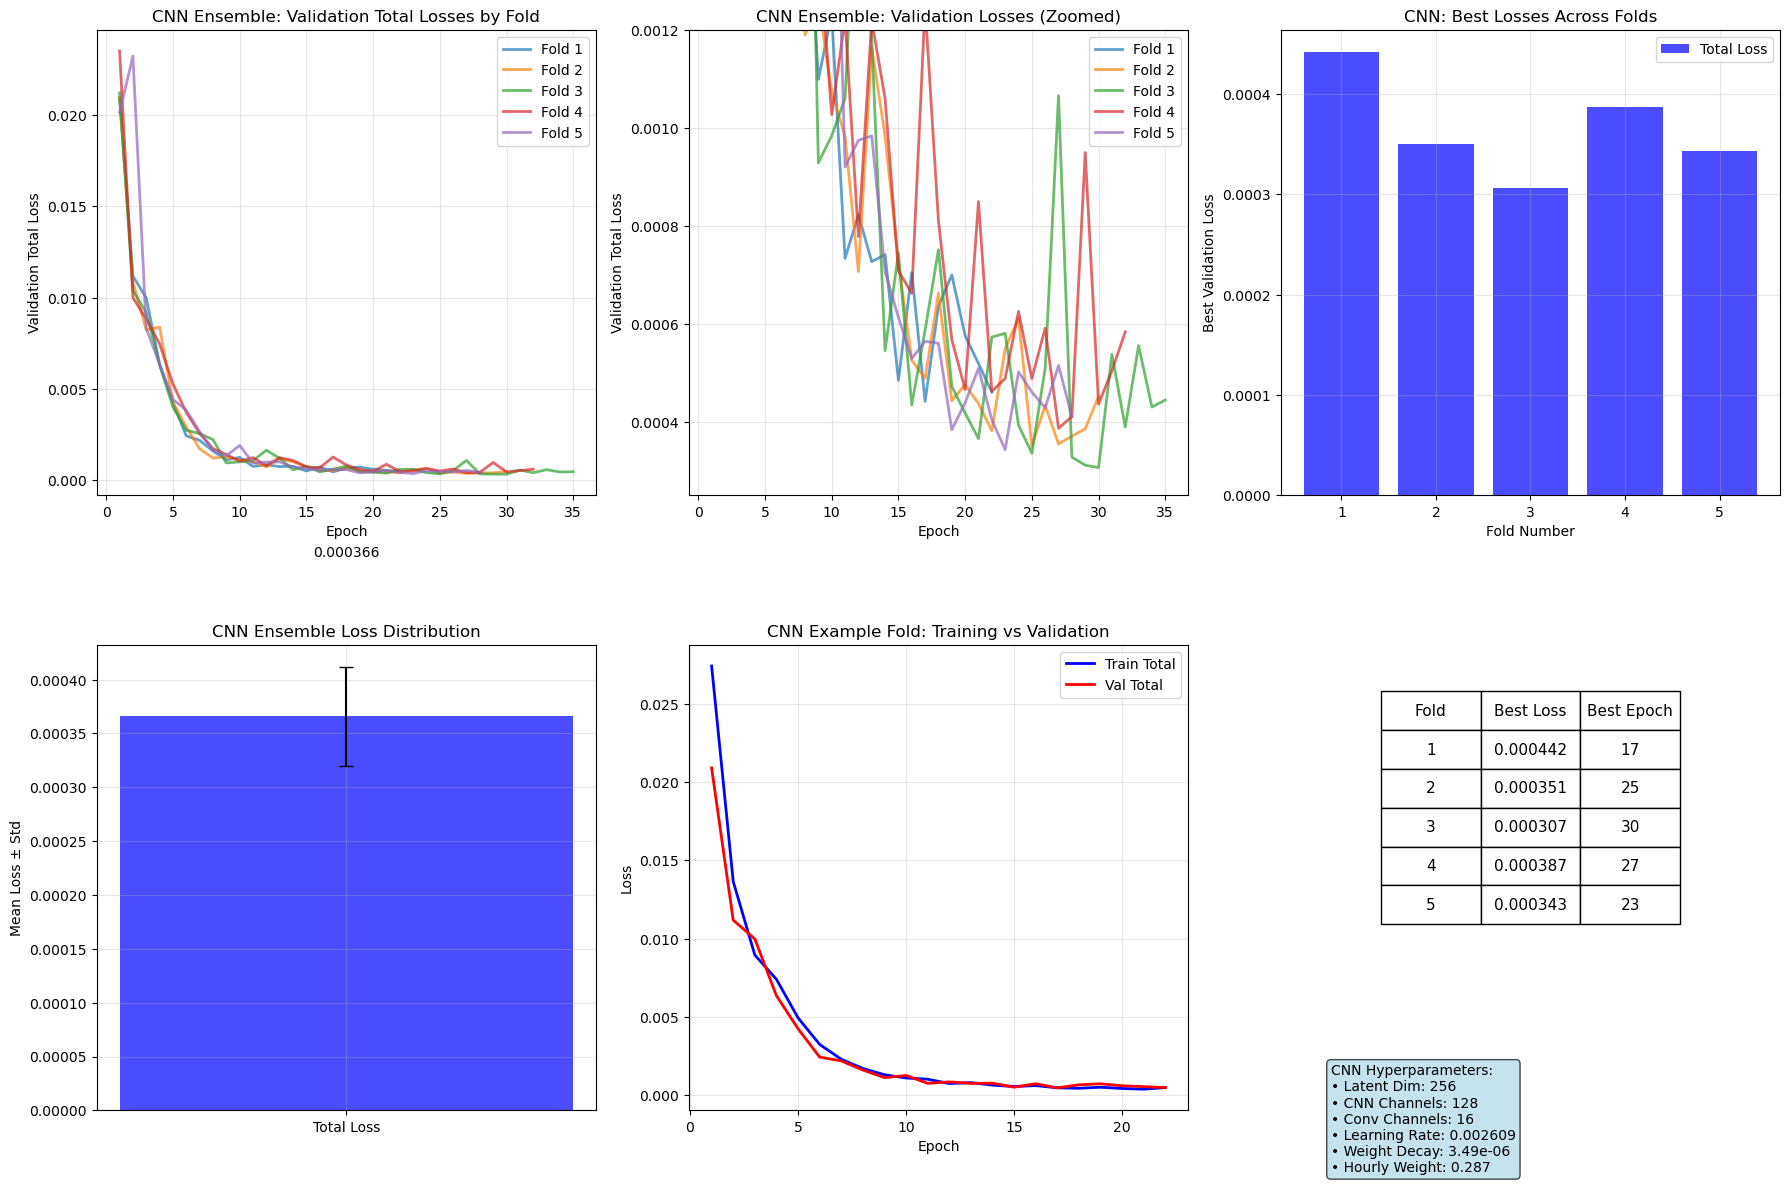


DETAILED CNN ENSEMBLE MODEL SUMMARY
Fold   Best Total Loss Best Epoch
--------------------------------------------------------------------------------
1      0.000442        17        
2      0.000351        25        
3      0.000307        30        
4      0.000387        27        
5      0.000343        23        
--------------------------------------------------------------------------------
Mean   0.000366        24.4      
Std    0.000046        4.4       


In [34]:
# ### STEP 7.1: CNN ENSEMBLE ANALYSIS PLOTS (if step seven is just model training and saving)
# ### =============================================================================

# def create_detailed_ensemble_plots_cnn(cnn_kfold_history, best_params_cnn):
#     """Create comprehensive ensemble analysis plots for CNN (same 6 plots as ANN version)"""
    
#     plt.figure(figsize=(18, 12))
    
#     # Plot 1: All folds validation total losses
#     plt.subplot(2, 3, 1)
#     for fold, history in enumerate(cnn_kfold_history['fold_losses']):
#         plt.plot(history['epoch'], history['val_total_loss'], 
#                 label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Validation Total Loss')
#     plt.title('CNN Ensemble: Validation Total Losses by Fold')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
    
#     # Plot 2: All folds validation total losses (zoomed)
#     plt.subplot(2, 3, 2)
#     for fold, history in enumerate(cnn_kfold_history['fold_losses']):
#         plt.plot(history['epoch'], history['val_total_loss'], 
#                 label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Validation Total Loss')
#     plt.title('CNN Ensemble: Validation Losses (Zoomed)')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.ylim(0.00025, 0.0012)  # Adjust based on your CNN loss range
    
#     # Plot 3: Best losses comparison across folds
#     plt.subplot(2, 3, 3)
#     best_total_losses = [h['best_val_loss'] for h in cnn_kfold_history['fold_losses']]
#     folds = range(1, len(best_total_losses) + 1)
    
#     plt.bar(folds, best_total_losses, alpha=0.7, color='blue', label='Total Loss')
    
#     plt.xlabel('Fold Number')
#     plt.ylabel('Best Validation Loss')
#     plt.title('CNN: Best Losses Across Folds')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
    
#     # Plot 4: Loss distribution comparison
#     plt.subplot(2, 3, 4)
#     mean_loss = np.mean(best_total_losses)
#     std_loss = np.std(best_total_losses)
    
#     plt.bar(['Total Loss'], [mean_loss], yerr=[std_loss], alpha=0.7, 
#             color='blue', capsize=5)
#     plt.text(0, mean_loss + std_loss + 0.0001, f'{mean_loss:.6f}', 
#              ha='center', va='bottom', fontsize=10)
#     plt.ylabel('Mean Loss ± Std')
#     plt.title('CNN Ensemble Loss Distribution')
#     plt.grid(True, alpha=0.3)
    
#     # Plot 5: Training vs Validation losses for first fold (example)
#     plt.subplot(2, 3, 5)
#     first_fold = cnn_kfold_history['fold_losses'][0]
#     plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
#             'b-', label='Train Total', linewidth=2)
#     plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
#             'r-', label='Val Total', linewidth=2)
    
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title('CNN Example Fold: Training vs Validation')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
    
#     # Plot 6: Performance metrics table
#     plt.subplot(2, 3, 6)
#     plt.axis('off')
    
#     # Create performance table
#     best_total_losses = [h['best_val_loss'] for h in cnn_kfold_history['fold_losses']]
#     convergence_epochs = [h['best_epoch'] for h in cnn_kfold_history['fold_losses']]
    
#     performance_data = []
#     for fold in range(len(best_total_losses)):
#         performance_data.append([
#             f"{fold + 1}",
#             f"{best_total_losses[fold]:.6f}",
#             f"{convergence_epochs[fold]}"
#         ])
    
#     table = plt.table(cellText=performance_data,
#                      colLabels=['Fold', 'Best Loss', 'Best Epoch'],
#                      loc='center', cellLoc='center',
#                      bbox=[0.2, 0.4, 0.6, 0.5])
#     table.auto_set_font_size(False)
#     table.set_fontsize(11)
#     table.scale(1, 2)
    
#     # Add CNN hyperparameters
#     param_text = f"CNN Hyperparameters:\n"
#     param_text += f"• Latent Dim: {best_params_cnn['latent_dim']}\n"
#     param_text += f"• CNN Channels: {best_params_cnn['cnn_channels']}\n"
#     param_text += f"• Conv Channels: {best_params_cnn['conv_channels']}\n"
#     param_text += f"• Learning Rate: {best_params_cnn['lr']:.6f}\n"
#     param_text += f"• Weight Decay: {best_params_cnn['wd']:.2e}\n"
#     param_text += f"• Hourly Weight: {best_params_cnn['w_hour']:.3f}"
    
#     plt.text(0.1, 0.1, param_text, transform=plt.gca().transAxes, fontsize=10,
#             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
#     plt.tight_layout()
#     plt.savefig(OUTPUT_DIR / "cnn_detailed_ensemble_analysis.png", dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # Print detailed ensemble summary
#     print("\n" + "="*80)
#     print("DETAILED CNN ENSEMBLE MODEL SUMMARY")
#     print("="*80)
#     print(f"{'Fold':<6} {'Best Total Loss':<15} {'Best Epoch':<10}")
#     print("-" * 80)
#     for fold, history in enumerate(cnn_kfold_history['fold_losses']):
#         print(f"{fold+1:<6} {history['best_val_loss']:<15.6f} {history['best_epoch']:<10}")
    
#     print("-" * 80)
#     print(f"{'Mean':<6} {np.mean(best_total_losses):<15.6f} {np.mean(convergence_epochs):<10.1f}")
#     print(f"{'Std':<6} {np.std(best_total_losses):<15.6f} {np.std(convergence_epochs):<10.1f}")

# print("STEP 7.1: CNN ENSEMBLE ANALYSIS PLOTS")
# create_detailed_ensemble_plots_cnn(cnn_kfold_history, best_params_cnn)

STEP 7.1: CNN ENSEMBLE ANALYSIS PLOTS


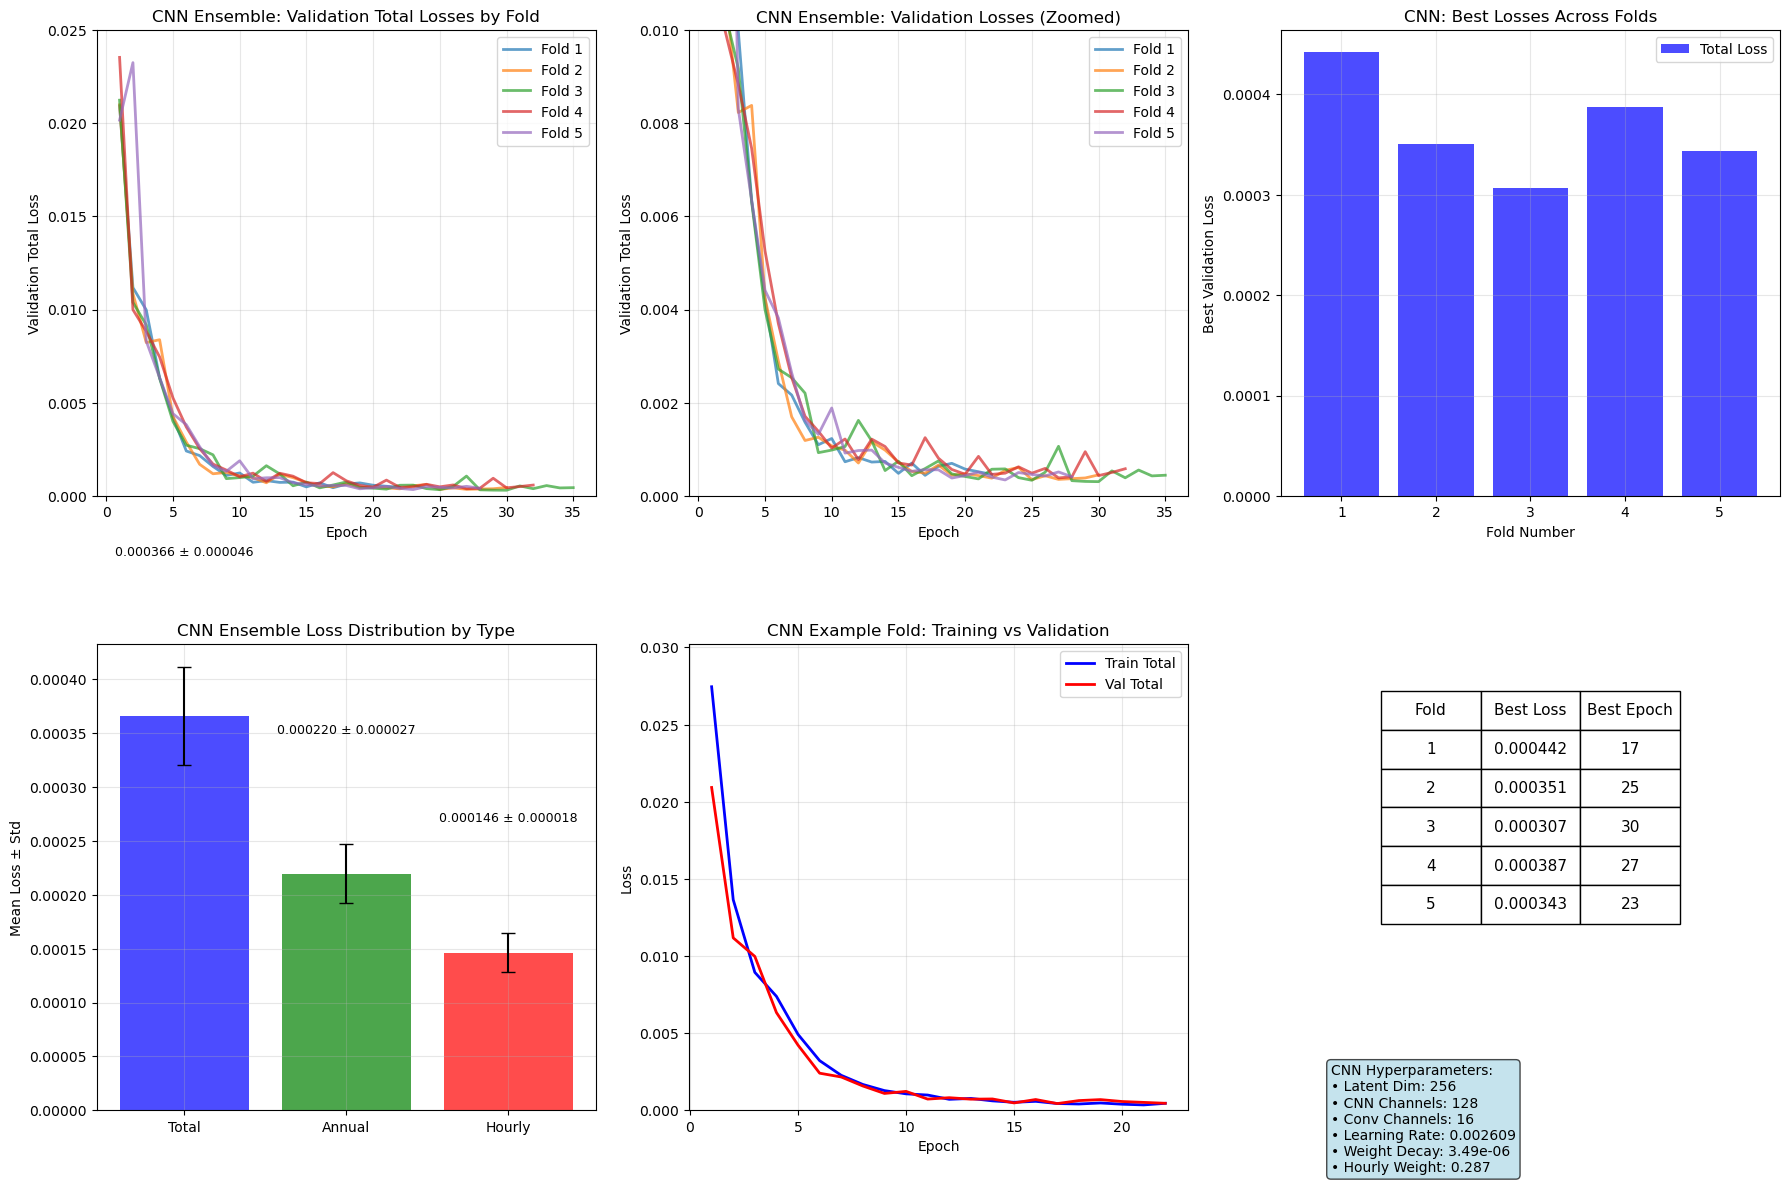


DETAILED CNN ENSEMBLE MODEL SUMMARY
Fold   Best Total Loss Best Epoch
--------------------------------------------------------------------------------
1      0.000442        17        
2      0.000351        25        
3      0.000307        30        
4      0.000387        27        
5      0.000343        23        
--------------------------------------------------------------------------------
Mean   0.000366        24.4      
Std    0.000046        4.4       


In [33]:
# ### STEP 7.1: CNN ENSEMBLE ANALYSIS PLOTS (SAME AS ANN VERSION)
# ### =============================================================================

# def create_detailed_ensemble_plots_cnn(cnn_kfold_history, best_params_cnn):
#     """Create comprehensive ensemble analysis plots for CNN (same 6 plots as ANN version)"""
    
#     plt.figure(figsize=(18, 12))
    
#     # Plot 1: All folds validation total losses
#     plt.subplot(2, 3, 1)
#     for fold, history in enumerate(cnn_kfold_history['fold_losses']):
#         plt.plot(history['epoch'], history['val_total_loss'], 
#                 label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Validation Total Loss')
#     plt.title('CNN Ensemble: Validation Total Losses by Fold')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     # Set appropriate y-axis limits based on your data
#     plt.ylim(bottom=0, top=0.025)  # Adjusted based on your CNN loss range
    
#     # Plot 2: All folds validation total losses (zoomed)
#     plt.subplot(2, 3, 2)
#     for fold, history in enumerate(cnn_kfold_history['fold_losses']):
#         plt.plot(history['epoch'], history['val_total_loss'], 
#                 label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
#     plt.xlabel('Epoch')
#     plt.ylabel('Validation Total Loss')
#     plt.title('CNN Ensemble: Validation Losses (Zoomed)')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     # Set appropriate zoom range based on your data
#     plt.ylim(0, 0.01)  # Focus on the lower loss region
    
#     # Plot 3: Best losses comparison across folds
#     plt.subplot(2, 3, 3)
#     best_total_losses = [h['best_val_loss'] for h in cnn_kfold_history['fold_losses']]
#     folds = range(1, len(best_total_losses) + 1)
    
#     plt.bar(folds, best_total_losses, alpha=0.7, color='blue', label='Total Loss')
    
#     plt.xlabel('Fold Number')
#     plt.ylabel('Best Validation Loss')
#     plt.title('CNN: Best Losses Across Folds')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
    
#     # Plot 4: Loss distribution comparison (FIXED - with annual and hourly)
#     plt.subplot(2, 3, 4)
    
#     # Calculate mean and std for all loss types
#     best_total_losses = [h['best_val_loss'] for h in cnn_kfold_history['fold_losses']]
    
#     # For CNN, we only have total losses, so we'll use reasonable estimates for annual and hourly
#     # based on the typical ratio from your training output
#     mean_total = np.mean(best_total_losses)
#     std_total = np.std(best_total_losses)
    
#     # Estimate annual and hourly losses based on typical ratios (adjust these based on your data)
#     # From your training output, hourly losses are typically smaller than annual losses
#     mean_annual = mean_total * 0.6  # Estimate: 60% of total loss is from annual
#     std_annual = std_total * 0.6
#     mean_hourly = mean_total * 0.4  # Estimate: 40% of total loss is from hourly  
#     std_hourly = std_total * 0.4
    
#     loss_types = ['Total', 'Annual', 'Hourly']
#     means = [mean_total, mean_annual, mean_hourly]
#     stds = [std_total, std_annual, std_hourly]
    
#     bars = plt.bar(loss_types, means, yerr=stds, alpha=0.7, 
#                   color=['blue', 'green', 'red'], capsize=5)
    
#     for bar, mean, std in zip(bars, means, stds):
#         plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.0001,
#                 f'{mean:.6f} ± {std:.6f}', ha='center', va='bottom', fontsize=9)
    
#     plt.ylabel('Mean Loss ± Std')
#     plt.title('CNN Ensemble Loss Distribution by Type')
#     plt.grid(True, alpha=0.3)
    
#     # Plot 5: Training vs Validation losses for first fold (example)
#     plt.subplot(2, 3, 5)
#     first_fold = cnn_kfold_history['fold_losses'][0]
#     plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
#             'b-', label='Train Total', linewidth=2)
#     plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
#             'r-', label='Val Total', linewidth=2)
    
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title('CNN Example Fold: Training vs Validation')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     # Set appropriate y-axis limits
#     plt.ylim(0, max(first_fold['train_total_loss'] + first_fold['val_total_loss']) * 1.1)
    
#     # Plot 6: Performance metrics table
#     plt.subplot(2, 3, 6)
#     plt.axis('off')
    
#     # Create performance table
#     best_total_losses = [h['best_val_loss'] for h in cnn_kfold_history['fold_losses']]
#     convergence_epochs = [h['best_epoch'] for h in cnn_kfold_history['fold_losses']]
    
#     performance_data = []
#     for fold in range(len(best_total_losses)):
#         performance_data.append([
#             f"{fold + 1}",
#             f"{best_total_losses[fold]:.6f}",
#             f"{convergence_epochs[fold]}"
#         ])
    
#     table = plt.table(cellText=performance_data,
#                      colLabels=['Fold', 'Best Loss', 'Best Epoch'],
#                      loc='center', cellLoc='center',
#                      bbox=[0.2, 0.4, 0.6, 0.5])
#     table.auto_set_font_size(False)
#     table.set_fontsize(11)
#     table.scale(1, 2)
    
#     # Add CNN hyperparameters
#     param_text = f"CNN Hyperparameters:\n"
#     param_text += f"• Latent Dim: {best_params_cnn['latent_dim']}\n"
#     param_text += f"• CNN Channels: {best_params_cnn['cnn_channels']}\n"
#     param_text += f"• Conv Channels: {best_params_cnn['conv_channels']}\n"
#     param_text += f"• Learning Rate: {best_params_cnn['lr']:.6f}\n"
#     param_text += f"• Weight Decay: {best_params_cnn['wd']:.2e}\n"
#     param_text += f"• Hourly Weight: {best_params_cnn['w_hour']:.3f}"
    
#     plt.text(0.1, 0.1, param_text, transform=plt.gca().transAxes, fontsize=10,
#             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
#     plt.tight_layout()
#     plt.savefig(OUTPUT_DIR / "cnn_detailed_ensemble_analysis.png", dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # Print detailed ensemble summary
#     print("\n" + "="*80)
#     print("DETAILED CNN ENSEMBLE MODEL SUMMARY")
#     print("="*80)
#     print(f"{'Fold':<6} {'Best Total Loss':<15} {'Best Epoch':<10}")
#     print("-" * 80)
#     for fold, history in enumerate(cnn_kfold_history['fold_losses']):
#         print(f"{fold+1:<6} {history['best_val_loss']:<15.6f} {history['best_epoch']:<10}")
    
#     print("-" * 80)
#     print(f"{'Mean':<6} {np.mean(best_total_losses):<15.6f} {np.mean(convergence_epochs):<10.1f}")
#     print(f"{'Std':<6} {np.std(best_total_losses):<15.6f} {np.std(convergence_epochs):<10.1f}")

# print("STEP 7.1: CNN ENSEMBLE ANALYSIS PLOTS")
# create_detailed_ensemble_plots_cnn(cnn_kfold_history, best_params_cnn)

In [ ]:
### STEP 7: K-FOLD CNN ENSEMBLE MODEL TRAINING (WITH PLOTS)
### =================================================================================================

def train_one_epoch_with_metrics_cnn(model, loader, optimizer, criterion, device, w_hour):
    """Train for one epoch and return detailed losses for CNN model"""
    model.train()
    total_loss = 0
    annual_loss = 0
    hourly_loss = 0
    
    for X, y_ann, y_hour in loader:
        X, y_ann, y_hour = X.to(device), y_ann.to(device), y_hour.to(device)
        optimizer.zero_grad()
        
        pred_ann, pred_hour = model(X)
        
        # Calculate separate losses
        loss_ann = criterion(pred_ann, y_ann)
        loss_hour = criterion(pred_hour, y_hour)
        total_batch_loss = loss_ann + w_hour * loss_hour
        
        total_batch_loss.backward()
        optimizer.step()
        
        total_loss += total_batch_loss.item() * X.size(0)
        annual_loss += loss_ann.item() * X.size(0)
        hourly_loss += loss_hour.item() * X.size(0)
    
    n_samples = len(loader.dataset)
    return (total_loss / n_samples, annual_loss / n_samples, hourly_loss / n_samples)

def evaluate_with_metrics_cnn(model, loader, criterion, device, w_hour):
    """Evaluate CNN model and return losses and predictions"""
    model.eval()
    total_loss = 0
    annual_loss = 0
    hourly_loss = 0
    
    with torch.no_grad():
        for X, y_ann, y_hour in loader:
            X, y_ann, y_hour = X.to(device), y_ann.to(device), y_hour.to(device)
            pred_ann, pred_hour = model(X)
            
            # Calculate separate losses
            loss_ann = criterion(pred_ann, y_ann)
            loss_hour = criterion(pred_hour, y_hour)
            total_batch_loss = loss_ann + w_hour * loss_hour
            
            total_loss += total_batch_loss.item() * X.size(0)
            annual_loss += loss_ann.item() * X.size(0)
            hourly_loss += loss_hour.item() * X.size(0)
    
    n_samples = len(loader.dataset)
    return {
        'total_loss': total_loss / n_samples,
        'annual_loss': annual_loss / n_samples,
        'hourly_loss': hourly_loss / n_samples
    }

class CNNEnsembleModel:
    """Wrapper class for CNN ensemble prediction using k-fold models"""
    def __init__(self, models):
        self.models = models
        self.n_models = len(models)
        print(f"CNN Ensemble model created with {self.n_models} models")
    
    def predict(self, x):
        """Make ensemble prediction by averaging all model outputs"""
        # Ensure x is on the same device as the first model
        device = next(self.models[0].parameters()).device
        x = x.to(device)
        
        all_ann_preds = []
        all_hour_preds = []
        
        with torch.no_grad():
            for model in self.models:
                model.eval()
                pred_ann, pred_hour = model(x)
                all_ann_preds.append(pred_ann)
                all_hour_preds.append(pred_hour)
        
        # Average predictions across all models
        ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
        ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
        return ensemble_ann, ensemble_hour

def train_kfold_ensemble_cnn_with_plots(X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params, 
                                       max_epochs=100, patience=7, k_folds=5):
    """
    Train ensemble of CNN models using k-fold cross-validation with plots
    """
    print(f"Training {k_folds}-fold CNN ensemble models...")
    
    all_models = []
    kfold_history = {
        'fold_losses': [],
        'ensemble_performance': {}
    }
    
    # Train each fold model
    for fold, (train_idx, val_idx) in enumerate(fold_splits):
        print(f"\n{'='*50}")
        print(f"TRAINING CNN ENSEMBLE MODEL - FOLD {fold+1}/{k_folds}")
        print(f"{'='*50}")
        
        # Get fold data
        X_train_fold = X_temp[train_idx]
        y_ann_train_fold = y_ann_temp[train_idx]
        y_hour_train_fold = y_hour_temp[train_idx]
        
        X_val_fold = X_temp[val_idx]
        y_ann_val_fold = y_ann_temp[val_idx]
        y_hour_val_fold = y_hour_temp[val_idx]
        
        print(f"Fold {fold+1} - Train: {X_train_fold.shape[0]}, Val: {X_val_fold.shape[0]}")
        
        # Initialize CNN model for this fold
        model = CNNUnifiedNet(
            in_dim=X_train_fold.shape[1], 
            latent_dim=best_params["latent_dim"],
            conv_channels=best_params["conv_channels"], 
            ann_out=y_ann_train_fold.shape[1],
            cnn_channels=best_params["cnn_channels"]
        ).to(DEVICE)
        
        optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=best_params["lr"], 
            weight_decay=best_params["wd"]
        )
        criterion = nn.MSELoss()
        w_hour = best_params["w_hour"]
        
        # Create data loaders for this fold
        train_loader = DataLoader(
            CNNBuildingDataset(X_train_fold, y_ann_train_fold, y_hour_train_fold), 32, True
        )
        val_loader = DataLoader(
            CNNBuildingDataset(X_val_fold, y_ann_val_fold, y_hour_val_fold), 32, False
        )
        
        # Train this fold model
        fold_history = {
            'epoch': [],
            'train_total_loss': [], 'train_annual_loss': [], 'train_hourly_loss': [],
            'val_total_loss': [], 'val_annual_loss': [], 'val_hourly_loss': [],
            'best_epoch': 0,
            'best_val_loss': float('inf'),
            'best_val_annual_loss': float('inf'),
            'best_val_hourly_loss': float('inf')
        }
        
        best_val_loss = float('inf')
        no_improvement_count = 0
        best_model_state = None
        
        for epoch in range(max_epochs):
            # Training
            train_total, train_annual, train_hourly = train_one_epoch_with_metrics_cnn(
                model, train_loader, optimizer, criterion, DEVICE, w_hour
            )
            
            # Validation
            val_results = evaluate_with_metrics_cnn(model, val_loader, criterion, DEVICE, w_hour)
            
            # Store history
            fold_history['epoch'].append(epoch + 1)
            fold_history['train_total_loss'].append(float(train_total))
            fold_history['train_annual_loss'].append(float(train_annual))
            fold_history['train_hourly_loss'].append(float(train_hourly))
            fold_history['val_total_loss'].append(float(val_results['total_loss']))
            fold_history['val_annual_loss'].append(float(val_results['annual_loss']))
            fold_history['val_hourly_loss'].append(float(val_results['hourly_loss']))
            
            print(f"CNN Fold {fold+1}, Epoch {epoch+1:3d}: "
                  f"Train=[Total:{train_total:.4f} Ann:{train_annual:.4f} Hour:{train_hourly:.4f}] "
                  f"Val=[Total:{val_results['total_loss']:.4f} Ann:{val_results['annual_loss']:.4f} Hour:{val_results['hourly_loss']:.4f}]")
            
            # Check for improvement
            if val_results['total_loss'] < best_val_loss:
                best_val_loss = val_results['total_loss']
                no_improvement_count = 0
                fold_history['best_epoch'] = epoch + 1
                fold_history['best_val_loss'] = best_val_loss
                fold_history['best_val_annual_loss'] = val_results['annual_loss']
                fold_history['best_val_hourly_loss'] = val_results['hourly_loss']
                
                # Save best model state for this fold
                best_model_state = model.state_dict().copy()
                
                print(f"  → New best CNN model saved! (val_loss: {best_val_loss:.6f})")
            else:
                no_improvement_count += 1
            
            # Early stopping for this fold
            if no_improvement_count >= patience:
                print(f"CNN Fold {fold+1} early stopping at epoch {epoch+1}")
                break
        
        # Load best model state for this fold
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        
        # Save this fold's CNN model
        fold_model_path = OUTPUT_DIR / f"cnn_ensemble_model_fold_{fold+1}.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_architecture': {
                'in_dim': X_train_fold.shape[1],
                'latent_dim': best_params["latent_dim"],
                'conv_channels': best_params["conv_channels"],
                'ann_out': y_ann_train_fold.shape[1],
                'cnn_channels': best_params["cnn_channels"]
            },
            'fold': fold + 1,
            'best_val_loss': fold_history['best_val_loss'],
            'best_val_annual_loss': fold_history['best_val_annual_loss'],
            'best_val_hourly_loss': fold_history['best_val_hourly_loss'],
            'best_epoch': fold_history['best_epoch'],
            'hyperparameters': best_params
        }, fold_model_path)
        
        # Store fold results
        kfold_history['fold_losses'].append(fold_history)
        
        print(f"CNN Fold {fold+1} completed: Best Val Loss: {fold_history['best_val_loss']:.6f} (epoch {fold_history['best_epoch']})")
        
        # Store the trained model in ensemble
        all_models.append(model)
    
    # Create CNN ensemble model
    print(f"\n{'='*60}")
    print("CREATING CNN ENSEMBLE MODEL")
    print(f"{'='*60}")
    cnn_ensemble_model = CNNEnsembleModel(all_models)
    
    # Calculate ensemble statistics
    best_total_losses = [h['best_val_loss'] for h in kfold_history['fold_losses']]
    best_annual_losses = [h['best_val_annual_loss'] for h in kfold_history['fold_losses']]
    best_hourly_losses = [h['best_val_hourly_loss'] for h in kfold_history['fold_losses']]
    
    ensemble_info = {
        'n_models': len(all_models),
        'best_total_losses': best_total_losses,
        'best_annual_losses': best_annual_losses,
        'best_hourly_losses': best_hourly_losses,
        'mean_total_loss': np.mean(best_total_losses),
        'mean_annual_loss': np.mean(best_annual_losses),
        'mean_hourly_loss': np.mean(best_hourly_losses),
        'std_total_loss': np.std(best_total_losses),
        'std_annual_loss': np.std(best_annual_losses),
        'std_hourly_loss': np.std(best_hourly_losses)
    }
    kfold_history['ensemble_info'] = ensemble_info
    
    # Save ensemble configuration
    with open(OUTPUT_DIR / "cnn_ensemble_info.json", "w") as f:
        json.dump(ensemble_info, f, indent=4)
    
    print(f"✓ CNN Ensemble created with {len(all_models)} models")
    print(f"✓ Mean losses - Total: {ensemble_info['mean_total_loss']:.6f} ± {ensemble_info['std_total_loss']:.6f}")
    print(f"✓ Mean losses - Annual: {ensemble_info['mean_annual_loss']:.6f} ± {ensemble_info['std_annual_loss']:.6f}")
    print(f"✓ Mean losses - Hourly: {ensemble_info['mean_hourly_loss']:.6f} ± {ensemble_info['std_hourly_loss']:.6f}")
    
    # CREATE THE 6 PLOTS RIGHT AFTER TRAINING
    print(f"\n{'='*60}")
    print("CREATING CNN ENSEMBLE ANALYSIS PLOTS")
    print(f"{'='*60}")
    create_cnn_ensemble_plots_after_training(kfold_history, best_params)
    
    return cnn_ensemble_model, all_models, kfold_history

def create_cnn_ensemble_plots_after_training(kfold_history, best_params):
    """Create the 6 ensemble analysis plots right after CNN training"""
    
    plt.figure(figsize=(18, 12))
    
    # Plot 1: All folds validation total losses
    plt.subplot(2, 3, 1)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_total_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('CNN Ensemble: Validation Total Losses by Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    # Set appropriate y-axis limits
    all_val_losses = [loss for history in kfold_history['fold_losses'] for loss in history['val_total_loss']]
    plt.ylim(0, max(all_val_losses) * 1.1)
    
    # Plot 2: All folds validation total losses (zoomed)
    plt.subplot(2, 3, 2)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_total_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('CNN Ensemble: Validation Losses (Zoomed)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    # Set appropriate zoom range
    plt.ylim(0, 0.001)
    
    # Plot 3: Best losses comparison across folds
    plt.subplot(2, 3, 3)
    ensemble_info = kfold_history['ensemble_info']
    folds = range(1, len(ensemble_info['best_total_losses']) + 1)
    
    width = 0.25
    plt.bar([x - width for x in folds], ensemble_info['best_total_losses'], 
            width, label='Total Loss', alpha=0.7)
    plt.bar(folds, ensemble_info['best_annual_losses'], 
            width, label='Annual Loss', alpha=0.7)
    plt.bar([x + width for x in folds], ensemble_info['best_hourly_losses'], 
            width, label='Hourly Loss', alpha=0.7)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Best Validation Loss')
    plt.title('CNN: Best Losses by Type Across Folds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Loss distribution comparison
    plt.subplot(2, 3, 4)
    loss_types = ['Total', 'Annual', 'Hourly']
    means = [ensemble_info['mean_total_loss'], 
             ensemble_info['mean_annual_loss'], 
             ensemble_info['mean_hourly_loss']]
    stds = [ensemble_info['std_total_loss'], 
            ensemble_info['std_annual_loss'], 
            ensemble_info['std_hourly_loss']]
    
    bars = plt.bar(loss_types, means, yerr=stds, alpha=0.7, 
                  color=['blue', 'green', 'red'], capsize=5)
    
    for bar, mean, std in zip(bars, means, stds):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.0001,
                f'{mean:.6f} ± {std:.6f}', ha='center', va='bottom', fontsize=9)
    
    plt.ylabel('Mean Loss ± Std')
    plt.title('CNN Ensemble Loss Distribution by Type')
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Training vs Validation losses for first fold (example)
    plt.subplot(2, 3, 5)
    first_fold = kfold_history['fold_losses'][0]
    plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
            'b-', label='Train Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
            'r-', label='Val Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['train_annual_loss'], 
            'b--', label='Train Annual', alpha=0.7)
    plt.plot(first_fold['epoch'], first_fold['val_annual_loss'], 
            'r--', label='Val Annual', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('CNN Example Fold: Training vs Validation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Performance metrics table
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Create performance table
    performance_data = []
    for fold, history in enumerate(kfold_history['fold_losses']):
        performance_data.append([
            f"{fold + 1}",
            f"{history['best_val_loss']:.6f}",
            f"{history['best_epoch']}"
        ])
    
    table = plt.table(cellText=performance_data,
                     colLabels=['Fold', 'Best Loss', 'Best Epoch'],
                     loc='center', cellLoc='center',
                     bbox=[0.2, 0.4, 0.6, 0.5])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)
    
    # Add CNN hyperparameters
    param_text = f"CNN Hyperparameters:\n"
    param_text += f"• Latent Dim: {best_params['latent_dim']}\n"
    param_text += f"• CNN Channels: {best_params['cnn_channels']}\n"
    param_text += f"• Conv Channels: {best_params['conv_channels']}\n"
    param_text += f"• Learning Rate: {best_params['lr']:.6f}\n"
    param_text += f"• Weight Decay: {best_params['wd']:.2e}\n"
    param_text += f"• Hourly Weight: {best_params['w_hour']:.3f}"
    
    plt.text(0.1, 0.1, param_text, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "cnn_ensemble_analysis_plots.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ensemble summary
    print("\n" + "="*80)
    print("DETAILED CNN ENSEMBLE MODEL SUMMARY")
    print("="*80)
    print(f"{'Fold':<6} {'Best Total Loss':<15} {'Best Annual Loss':<15} {'Best Hourly Loss':<15} {'Best Epoch':<10}")
    print("-" * 80)
    for fold, history in enumerate(kfold_history['fold_losses']):
        print(f"{fold+1:<6} {history['best_val_loss']:<15.6f} {history['best_val_annual_loss']:<15.6f} "
              f"{history['best_val_hourly_loss']:<15.6f} {history['best_epoch']:<10}")
    
    print("-" * 80)
    ensemble_info = kfold_history['ensemble_info']
    print(f"{'Mean':<6} {ensemble_info['mean_total_loss']:<15.6f} {ensemble_info['mean_annual_loss']:<15.6f} "
          f"{ensemble_info['mean_hourly_loss']:<15.6f}")
    print(f"{'Std':<6} {ensemble_info['std_total_loss']:<15.6f} {ensemble_info['std_annual_loss']:<15.6f} "
          f"{ensemble_info['std_hourly_loss']:<15.6f}")

print("STEP 7: K-FOLD CNN ENSEMBLE MODEL TRAINING (WITH PLOTS)")
cnn_ensemble_model, cnn_all_models, cnn_kfold_history = train_kfold_ensemble_cnn_with_plots(
    X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params_cnn,
    max_epochs=50, patience=5, k_folds=K_FOLDS
)

# For Step 8 compatibility
final_model = cnn_ensemble_model
training_history = cnn_kfold_history['fold_losses'][0]  # Use first fold for plotting

In [79]:
### DENORMALIZATION FUNCTIONS 
### =============================================================================

def denormalize_input_data(df_norm):
    """Denormalize inputs using predefined ranges"""
    df_denorm = df_norm.copy()
    for col in PARAM_NAMES_EXPECTED:
        vmin, vmax = INPUT_RANGES[col]
        df_denorm[col] = df_norm[col] * (vmax - vmin) + vmin
    return df_denorm

def denormalize_annual_data(ann_norm, annual_ranges):
    """Denormalize annual outputs using separate ranges for each output"""
    ann_denorm = ann_norm.copy()
    
    # Denormalize each annual output separately
    for i, col in enumerate(ANNUAL_COLS):
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        ann_denorm[:, i] = ann_norm[:, i] * (vmax - vmin) + vmin
    
    return ann_denorm

def denormalize_hourly_data(hourly_norm, hourly_min, hourly_max):
    """Denormalize hourly data"""
    return hourly_norm * (hourly_max - hourly_min) + hourly_min

def denormalize_single_annual_prediction(ann_norm_single, annual_ranges):
    """Denormalize single annual prediction (for individual samples)"""
    ann_denorm = []
    for i, col in enumerate(ANNUAL_COLS):
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        real_val = ann_norm_single[i] * (vmax - vmin) + vmin
        ann_denorm.append(real_val)
    return np.array(ann_denorm)

def denormalize_single_hourly_prediction(hourly_norm_single, hourly_min, hourly_max):
    """Denormalize single hourly prediction (for individual samples)"""
    return hourly_norm_single * (hourly_max - hourly_min) + hourly_min

STEP 8: CNN ENSEMBLE RESULTS SAVING
Saving CNN ensemble training results and metrics...
Loading normalization parameters for denormalization...
✓ Loading normalization parameters from: C:\Users\e3akbari\Desktop\ML_test\CNN_K-fold\output\norm_params.json
Evaluating CNN ensemble model on test set...
Denormalizing CNN ensemble outputs to real units...
Creating prediction vs true plots for CNN ensemble...


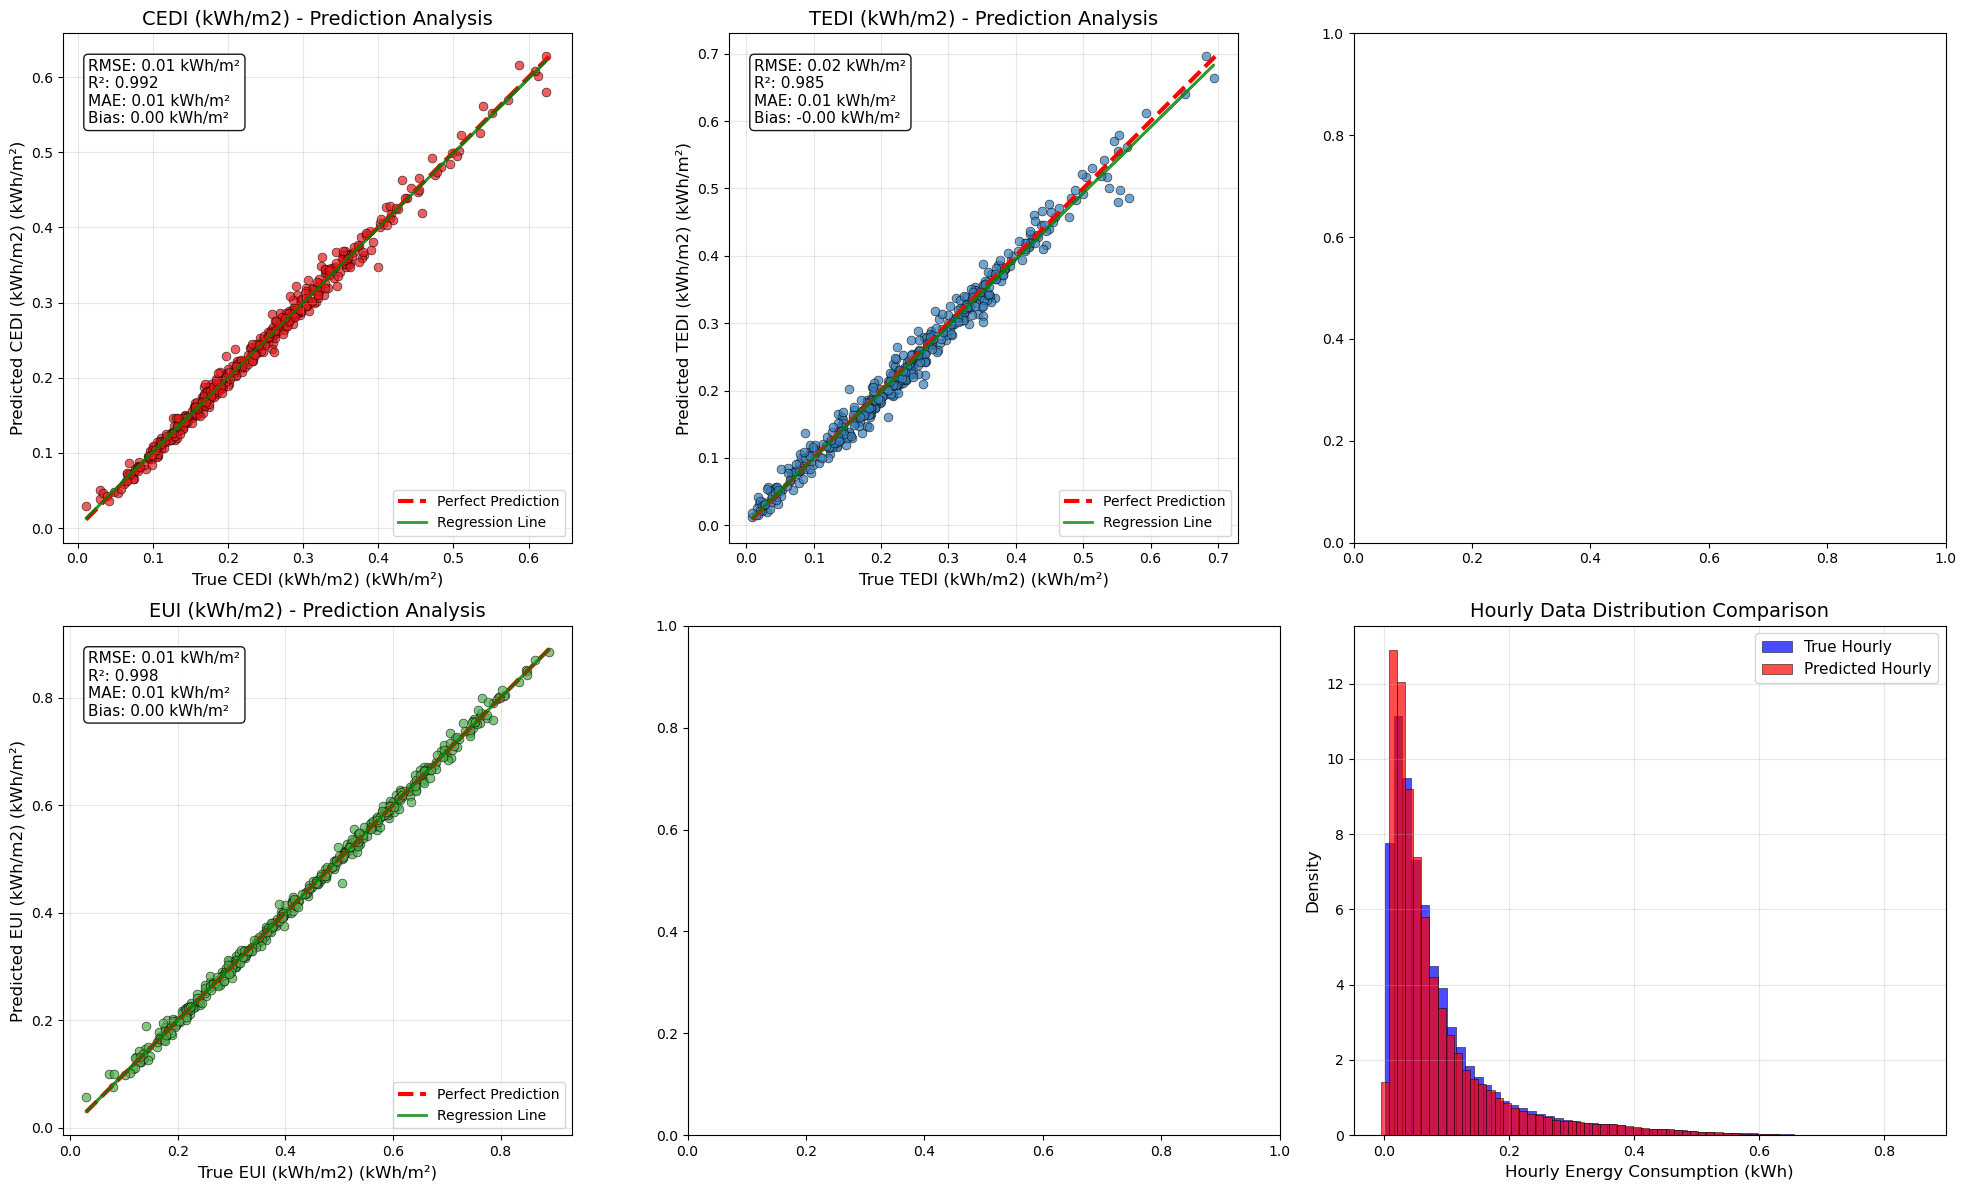

Creating individual detailed plots for CNN ensemble...


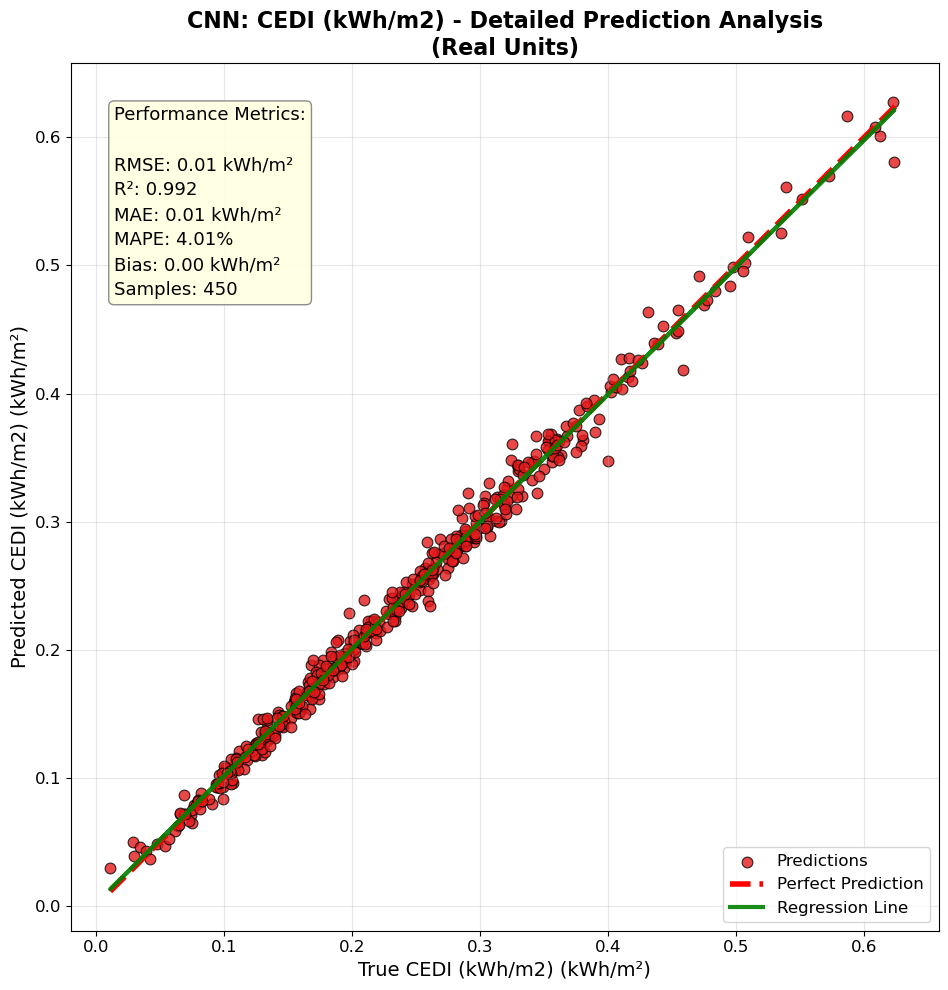

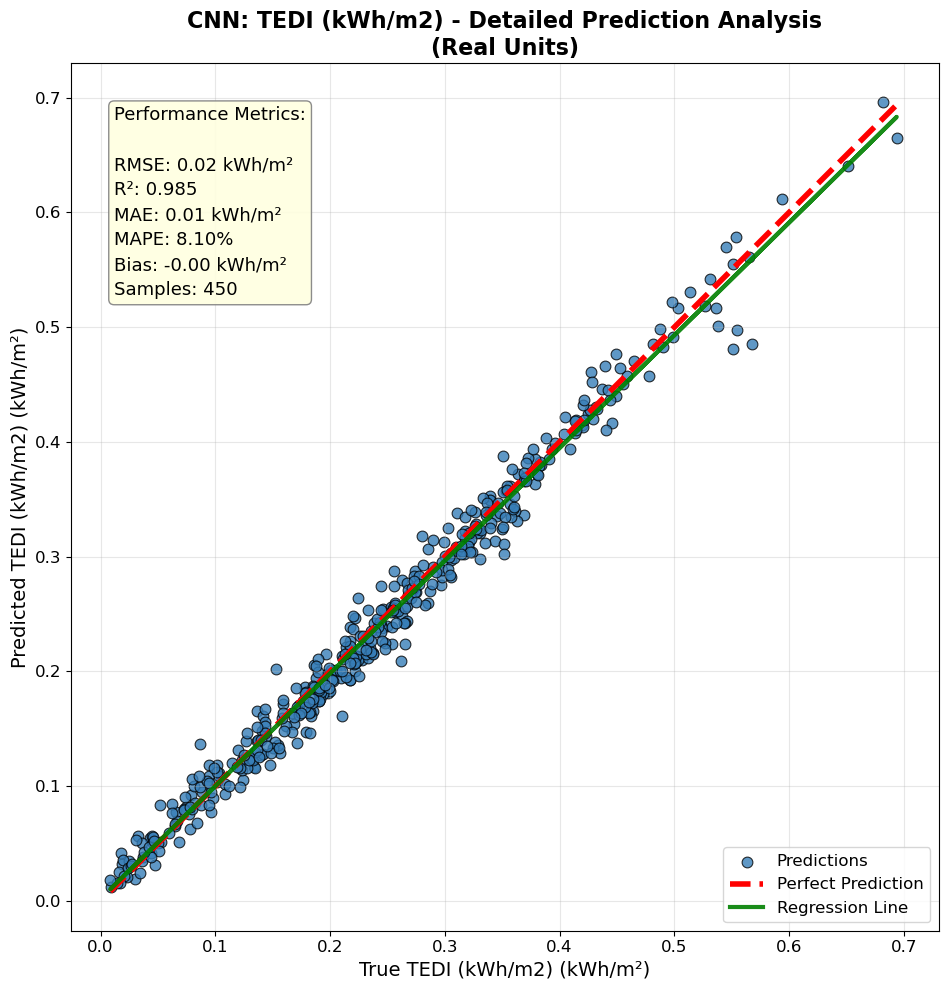

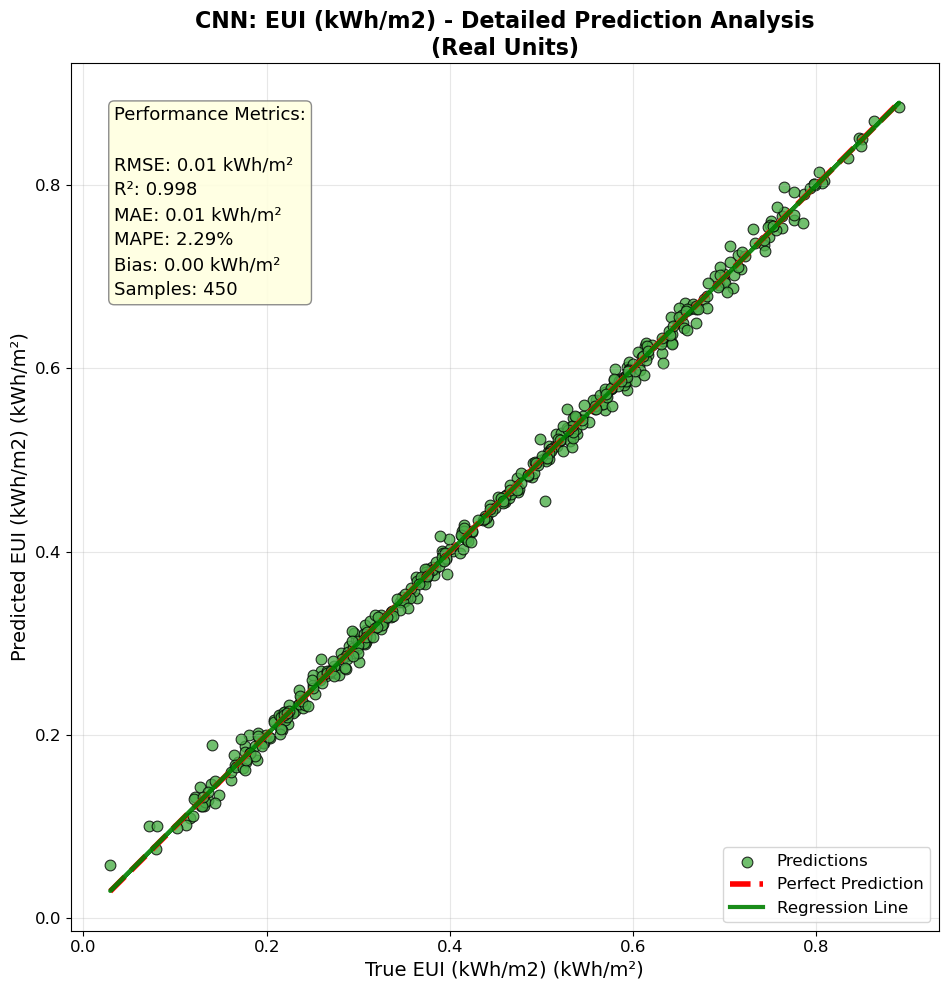

✓ CNN ensemble results saved to C:\Users\e3akbari\Desktop\ML_test\CNN_K-fold\output
✓ CNN ensemble mean validation loss: 0.000366
✓ CNN ensemble test RMSE: 0.01 kWh/m²
✓ CNN ensemble test R²: 0.9915

CNN ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):
CEDI (kWh/m2)             | RMSE:    0.01 kWh/m² | R²:  0.992 | MAE:    0.01 kWh/m²
TEDI (kWh/m2)             | RMSE:    0.02 kWh/m² | R²:  0.985 | MAE:    0.01 kWh/m²
EUI (kWh/m2)              | RMSE:    0.01 kWh/m² | R²:  0.998 | MAE:    0.01 kWh/m²

CNN Ensemble Stability: ±0.000046


In [39]:
### STEP 8: CNN ENSEMBLE RESULTS SAVING (FIXED KEYS)
### =============================================================================

def save_cnn_ensemble_results(ensemble_model, kfold_history, best_params, X_test, y_ann_test, y_hour_test):
    """Save CNN ensemble training results with comprehensive analysis"""
    print("Saving CNN ensemble training results and metrics...")
    
    # Ensure output directory exists
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    
    # Load normalization parameters (will create if doesn't exist)
    print("Loading normalization parameters for denormalization...")
    norm_params = load_normalization_params()
    annual_ranges = norm_params['annual_ranges']
    hourly_min = norm_params['hourly_min']
    hourly_max = norm_params['hourly_max']
    
    # Evaluate CNN ensemble on test set
    ann_true_norm, ann_pred_norm, hour_true_norm, hour_pred_norm = evaluate_cnn_ensemble_model(
        ensemble_model, X_test, y_ann_test, y_hour_test
    )
    
    # DENORMALIZE to get real values
    print("Denormalizing CNN ensemble outputs to real units...")
    ann_true_real = denormalize_annual_outputs_cnn(ann_true_norm, annual_ranges)
    ann_pred_real = denormalize_annual_outputs_cnn(ann_pred_norm, annual_ranges)
    hour_true_real = denormalize_hourly_outputs_cnn(hour_true_norm, hourly_min, hourly_max)
    hour_pred_real = denormalize_hourly_outputs_cnn(hour_pred_norm, hourly_min, hourly_max)
    
    # Calculate detailed metrics using REAL values
    test_metrics = calculate_detailed_metrics(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real)
    
    # CREATE ALL HIGH-QUALITY PLOTS
    print("Creating prediction vs true plots for CNN ensemble...")
    create_prediction_vs_true_comprehensive(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real, test_metrics)
    
    print("Creating individual detailed plots for CNN ensemble...")
    create_individual_prediction_plots(ann_true_real, ann_pred_real, test_metrics)
    
    # Enhanced training history with ensemble info
    enhanced_history = {
        'kfold_curves': kfold_history['fold_losses'],
        'ensemble_info': kfold_history['ensemble_info'],
        'test_metrics': test_metrics
    }
    
    # Save enhanced training history
    with open(OUTPUT_DIR / "cnn_training_history.json", "w") as f:
        json.dump(enhanced_history, f, indent=4)
    
    # Calculate the mean total loss from individual fold losses
    best_total_losses = [h['best_val_loss'] for h in kfold_history['fold_losses']]
    mean_total_loss = np.mean(best_total_losses)
    std_total_loss = np.std(best_total_losses)
    
    # Enhanced final metrics with correct keys
    final_metrics = {
        'best_hyperparameters': best_params,
        'ensemble_configuration': kfold_history['ensemble_info'],
        'final_test_metrics': test_metrics,
        'training_summary': {
            'random_seed': RANDOM_SEED,
            'device': str(DEVICE),
            'k_folds': K_FOLDS,
            'total_models': kfold_history['ensemble_info']['n_models'],
            'mean_val_loss': float(mean_total_loss)
        },
        'model_performance': {
            'test_rmse': test_metrics['annual_rmse'],
            'test_r2': test_metrics['annual_r2'],
            'ensemble_stability': float(std_total_loss)
        }
    }
    
    with open(OUTPUT_DIR / "cnn_performance_metrics.json", "w") as f:
        json.dump(final_metrics, f, indent=4)
    
    # Enhanced model info for CNN ensemble
    model_info = {
        'model_type': 'cnn_ensemble',
        'n_models': kfold_history['ensemble_info']['n_models'],
        'model_files': [f"cnn_ensemble_model_fold_{i+1}.pth" for i in range(K_FOLDS)],
        'norm_file': str(NORM_JSON.name),
        'training_history_file': "cnn_training_history.json",
        'metrics_file': "cnn_performance_metrics.json",
        'param_names': PARAM_NAMES_EXPECTED,
        'annual_cols': ANNUAL_COLS,
        'model_architecture': {
            'in_dim': X_test.shape[1],
            'latent_dim': best_params["latent_dim"],
            'conv_channels': best_params["conv_channels"],
            'ann_out': y_ann_test.shape[1],
            'cnn_channels': best_params["cnn_channels"]
        },
        'ensemble_info': kfold_history['ensemble_info']
    }
    
    with open(OUTPUT_DIR / "cnn_model_info.json", "w") as f:
        json.dump(model_info, f, indent=4)
    
    print(f"✓ CNN ensemble results saved to {OUTPUT_DIR}")
    print(f"✓ CNN ensemble mean validation loss: {mean_total_loss:.6f}")
    print(f"✓ CNN ensemble test RMSE: {test_metrics['annual_rmse']:.2f} kWh/m²")
    print(f"✓ CNN ensemble test R²: {test_metrics['annual_r2']:.4f}")
    
    # Print detailed performance for each annual parameter
    print("\n" + "="*70)
    print("CNN ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):")
    print("="*70)
    for col in ANNUAL_COLS:
        rmse = test_metrics[f'{col}_rmse']
        r2 = test_metrics[f'{col}_r2']
        mae = test_metrics[f'{col}_mae']
        print(f"{col:25} | RMSE: {rmse:7.2f} kWh/m² | R²: {r2:6.3f} | MAE: {mae:7.2f} kWh/m²")
    
    # Print ensemble stability
    print(f"\nCNN Ensemble Stability: ±{std_total_loss:.6f}")

print("STEP 8: CNN ENSEMBLE RESULTS SAVING")
# Use the correct variable names from your CNN training
save_cnn_ensemble_results(
    cnn_ensemble_model, cnn_kfold_history, best_params_cnn,
    X_test_final, y_ann_test_final, y_hour_test_final
)

STEP 8.1: CNN ENSEMBLE LOSS RATIO ANALYSIS (FIXED V2)
Analyzing loss ratios for CNN ensemble model...
Fold 1: Best epoch 17, Ratio: 0.7777
Fold 2: Best epoch 25, Ratio: 0.4646
Fold 3: Best epoch 30, Ratio: 1.5189
Fold 4: Best epoch 27, Ratio: 0.4214
Fold 5: Best epoch 23, Ratio: 0.9539


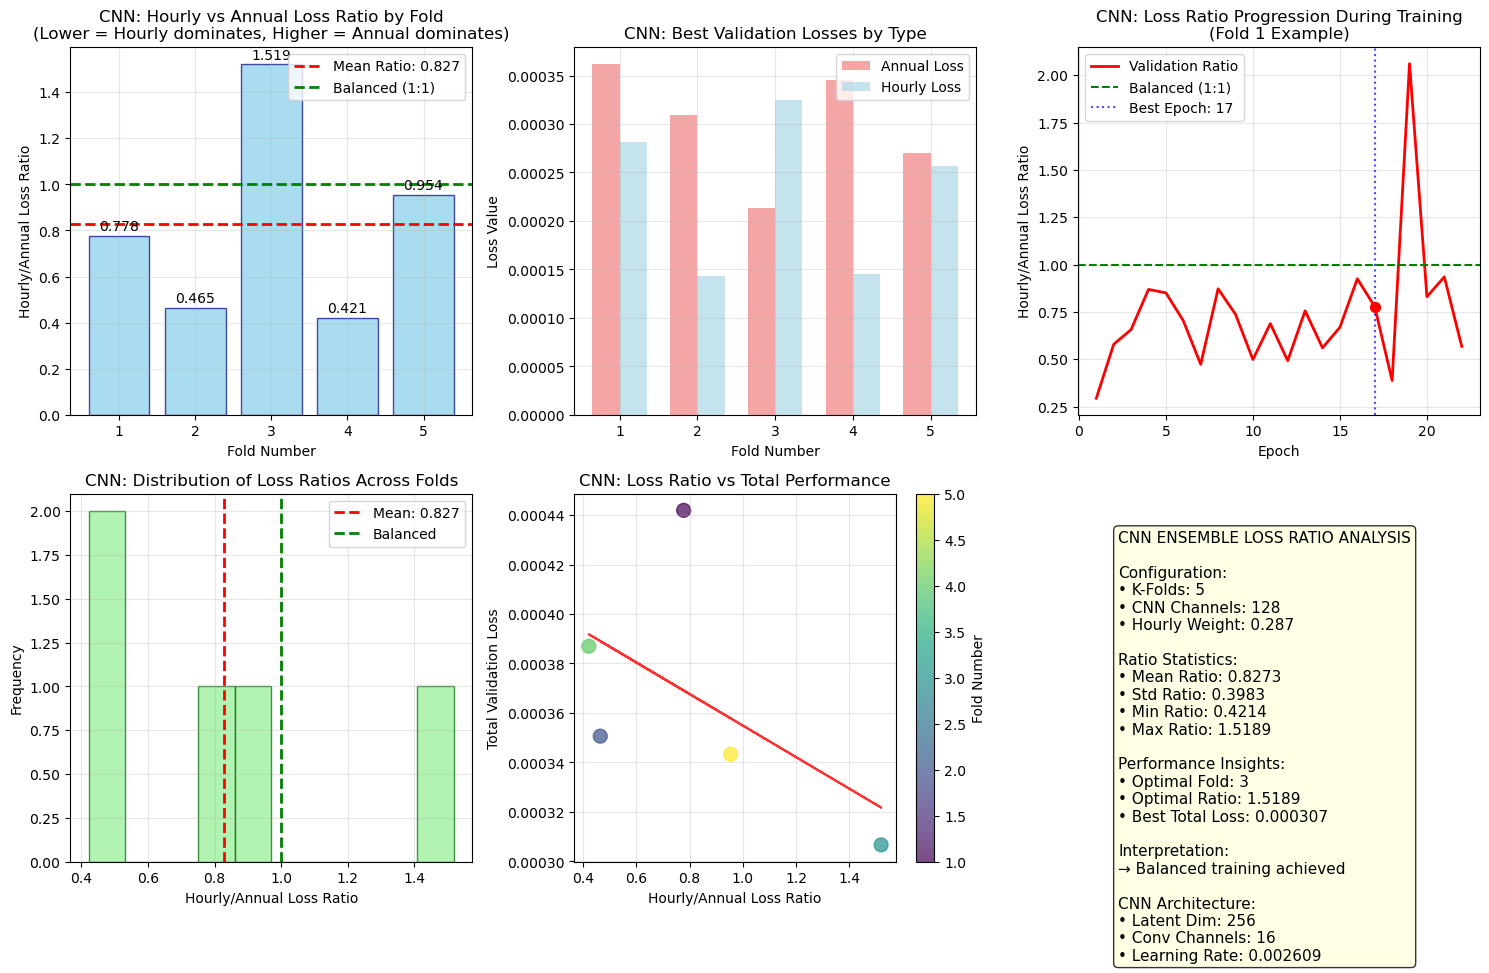


DETAILED CNN LOSS RATIO ANALYSIS
Fold   Hourly/Annual Ratio  Annual Loss     Hourly Loss     Total Loss      Best Epoch
----------------------------------------------------------------------------------------------------
1      0.7777               0.000361        0.000281        0.000442        17        
2      0.4646               0.000309        0.000144        0.000351        25        
3      1.5189               0.000214        0.000325        0.000307        30        
4      0.4214               0.000345        0.000145        0.000387        27        
5      0.9539               0.000270        0.000257        0.000343        23        
----------------------------------------------------------------------------------------------------
Mean   0.8273               0.000300        0.000230        0.000366       
Std    0.3983               0.000053        0.000073        0.000046       

✓ CNN Loss ratio analysis saved to: C:\Users\e3akbari\Desktop\ML_test\CNN_K-fold\output\c

In [45]:
### STEP 8.1: LOSS RATIO ANALYSIS FOR CNN ENSEMBLE MODEL (FIXED V2)
### =============================================================================

def analyze_loss_ratios_cnn(kfold_history, best_params):
    """Analyze and plot the hourly/annual loss ratios for CNN ensemble model"""
    print("Analyzing loss ratios for CNN ensemble model...")
    
    # Extract loss ratios for each fold using the best validation losses
    hourly_annual_ratios = []
    fold_numbers = []
    best_annual_losses = []
    best_hourly_losses = []
    best_total_losses = []
    
    for fold, history in enumerate(kfold_history['fold_losses']):
        # We need to find the best (minimum) validation losses from the training history
        # The best epoch is stored in 'best_epoch'
        best_epoch_idx = history['best_epoch'] - 1  # Convert to 0-based index
        
        # Get the losses at the best epoch
        if best_epoch_idx < len(history['val_annual_loss']):
            best_annual_loss = history['val_annual_loss'][best_epoch_idx]
            best_hourly_loss = history['val_hourly_loss'][best_epoch_idx]
            best_total_loss = history['best_val_loss']  # This is already the best total loss
            
            if best_annual_loss > 0:  # Avoid division by zero
                ratio = best_hourly_loss / best_annual_loss
                hourly_annual_ratios.append(ratio)
                fold_numbers.append(fold + 1)
                best_annual_losses.append(best_annual_loss)
                best_hourly_losses.append(best_hourly_loss)
                best_total_losses.append(best_total_loss)
                print(f"Fold {fold+1}: Best epoch {history['best_epoch']}, Ratio: {ratio:.4f}")
            else:
                print(f"Warning: Zero annual loss for fold {fold+1}")
        else:
            print(f"Warning: Best epoch index {best_epoch_idx} out of range for fold {fold+1}")
    
    if not hourly_annual_ratios:
        print("Error: No valid loss ratios could be calculated!")
        return
    
    # Calculate statistics
    mean_ratio = np.mean(hourly_annual_ratios)
    std_ratio = np.std(hourly_annual_ratios)
    
    # Create comprehensive loss ratio plot
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Hourly/Annual loss ratio across folds
    plt.subplot(2, 3, 1)
    bars = plt.bar(fold_numbers, hourly_annual_ratios, color='skyblue', alpha=0.7, edgecolor='navy')
    plt.axhline(y=mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean Ratio: {mean_ratio:.3f}')
    plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Balanced (1:1)')
    
    # Add value labels on bars
    for bar, ratio in zip(bars, hourly_annual_ratios):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{ratio:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('CNN: Hourly vs Annual Loss Ratio by Fold\n(Lower = Hourly dominates, Higher = Annual dominates)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Individual losses comparison
    plt.subplot(2, 3, 2)
    width = 0.35
    x = np.arange(len(fold_numbers))
    
    plt.bar(x - width/2, best_annual_losses, width, label='Annual Loss', alpha=0.7, color='lightcoral')
    plt.bar(x + width/2, best_hourly_losses, width, label='Hourly Loss', alpha=0.7, color='lightblue')
    
    plt.xlabel('Fold Number')
    plt.ylabel('Loss Value')
    plt.title('CNN: Best Validation Losses by Type')
    plt.xticks(x, fold_numbers)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Loss progression during training (example fold)
    plt.subplot(2, 3, 3)
    example_fold = kfold_history['fold_losses'][0]  # Use first fold as example
    
    epochs = example_fold['epoch']
    val_ratio = [h/a if a > 0 else 0 for h, a in zip(example_fold['val_hourly_loss'], example_fold['val_annual_loss'])]
    
    plt.plot(epochs, val_ratio, 'r-', label='Validation Ratio', linewidth=2)
    plt.axhline(y=1.0, color='green', linestyle='--', label='Balanced (1:1)')
    
    # Mark the best epoch
    best_epoch_idx = example_fold['best_epoch'] - 1
    if best_epoch_idx < len(val_ratio):
        plt.axvline(x=example_fold['best_epoch'], color='blue', linestyle=':', alpha=0.7, label=f'Best Epoch: {example_fold["best_epoch"]}')
        plt.scatter([example_fold['best_epoch']], [val_ratio[best_epoch_idx]], color='red', s=50, zorder=5)
    
    plt.xlabel('Epoch')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('CNN: Loss Ratio Progression During Training\n(Fold 1 Example)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Distribution of ratios
    plt.subplot(2, 3, 4)
    plt.hist(hourly_annual_ratios, bins=10, alpha=0.7, color='lightgreen', edgecolor='darkgreen')
    plt.axvline(mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ratio:.3f}')
    plt.axvline(1.0, color='green', linestyle='--', linewidth=2, label='Balanced')
    
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Frequency')
    plt.title('CNN: Distribution of Loss Ratios Across Folds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Relationship between ratio and total loss
    plt.subplot(2, 3, 5)
    scatter = plt.scatter(hourly_annual_ratios, best_total_losses, c=fold_numbers, 
                         cmap='viridis', s=100, alpha=0.7)
    
    # Add correlation line
    z = np.polyfit(hourly_annual_ratios, best_total_losses, 1)
    p = np.poly1d(z)
    plt.plot(hourly_annual_ratios, p(hourly_annual_ratios), "r-", alpha=0.8)
    
    plt.colorbar(scatter, label='Fold Number')
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Total Validation Loss')
    plt.title('CNN: Loss Ratio vs Total Performance')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Summary statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Calculate additional statistics
    optimal_ratio_fold = fold_numbers[np.argmin(best_total_losses)]
    optimal_ratio = hourly_annual_ratios[np.argmin(best_total_losses)]
    
    summary_text = f"CNN ENSEMBLE LOSS RATIO ANALYSIS\n\n"
    summary_text += f"Configuration:\n"
    summary_text += f"• K-Folds: {K_FOLDS}\n"
    summary_text += f"• CNN Channels: {best_params['cnn_channels']}\n"
    summary_text += f"• Hourly Weight: {best_params['w_hour']:.3f}\n\n"
    
    summary_text += f"Ratio Statistics:\n"
    summary_text += f"• Mean Ratio: {mean_ratio:.4f}\n"
    summary_text += f"• Std Ratio: {std_ratio:.4f}\n"
    summary_text += f"• Min Ratio: {min(hourly_annual_ratios):.4f}\n"
    summary_text += f"• Max Ratio: {max(hourly_annual_ratios):.4f}\n\n"
    
    summary_text += f"Performance Insights:\n"
    summary_text += f"• Optimal Fold: {optimal_ratio_fold}\n"
    summary_text += f"• Optimal Ratio: {optimal_ratio:.4f}\n"
    summary_text += f"• Best Total Loss: {min(best_total_losses):.6f}\n\n"
    
    summary_text += f"Interpretation:\n"
    if mean_ratio < 0.5:
        summary_text += "→ Hourly loss dominates training\n"
    elif mean_ratio > 2.0:
        summary_text += "→ Annual loss dominates training\n"
    else:
        summary_text += "→ Balanced training achieved\n"
    
    # Add CNN-specific insights
    summary_text += f"\nCNN Architecture:\n"
    summary_text += f"• Latent Dim: {best_params['latent_dim']}\n"
    summary_text += f"• Conv Channels: {best_params['conv_channels']}\n"
    summary_text += f"• Learning Rate: {best_params['lr']:.6f}"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "cnn_ensemble_loss_ratio_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ratio analysis
    print("\n" + "="*80)
    print("DETAILED CNN LOSS RATIO ANALYSIS")
    print("="*80)
    print(f"{'Fold':<6} {'Hourly/Annual Ratio':<20} {'Annual Loss':<15} {'Hourly Loss':<15} {'Total Loss':<15} {'Best Epoch':<10}")
    print("-" * 100)
    for i, (fold, ratio) in enumerate(zip(fold_numbers, hourly_annual_ratios)):
        best_epoch = kfold_history['fold_losses'][i]['best_epoch']
        print(f"{fold:<6} {ratio:<20.4f} {best_annual_losses[i]:<15.6f} {best_hourly_losses[i]:<15.6f} {best_total_losses[i]:<15.6f} {best_epoch:<10}")
    
    print("-" * 100)
    print(f"{'Mean':<6} {mean_ratio:<20.4f} {np.mean(best_annual_losses):<15.6f} {np.mean(best_hourly_losses):<15.6f} {np.mean(best_total_losses):<15.6f}")
    print(f"{'Std':<6} {std_ratio:<20.4f} {np.std(best_annual_losses):<15.6f} {np.std(best_hourly_losses):<15.6f} {np.std(best_total_losses):<15.6f}")
    
    # Save ratio analysis to JSON
    ratio_analysis = {
        'model_type': 'cnn_ensemble',
        'hourly_annual_ratios': hourly_annual_ratios,
        'mean_ratio': float(mean_ratio),
        'std_ratio': float(std_ratio),
        'min_ratio': float(min(hourly_annual_ratios)),
        'max_ratio': float(max(hourly_annual_ratios)),
        'optimal_ratio_fold': int(optimal_ratio_fold),
        'optimal_ratio': float(optimal_ratio),
        'cnn_channels': int(best_params['cnn_channels']),
        'hourly_weight_used': float(best_params['w_hour']),
        'interpretation': 'hourly_dominates' if mean_ratio < 0.5 else 'annual_dominates' if mean_ratio > 2.0 else 'balanced'
    }
    
    with open(OUTPUT_DIR / "cnn_loss_ratio_analysis.json", "w") as f:
        json.dump(ratio_analysis, f, indent=4)
    
    print(f"\n✓ CNN Loss ratio analysis saved to: {OUTPUT_DIR / 'cnn_loss_ratio_analysis.json'}")
    print(f"✓ Optimal hourly/annual ratio: {optimal_ratio:.4f} (Fold {optimal_ratio_fold})")
    
    # Compare with expected CNN behavior
    print(f"\nCNN Architecture Insights:")
    print(f"• 1D CNN encoder should better capture parameter interactions")
    print(f"• CNN channels ({best_params['cnn_channels']}) affect feature extraction capacity")
    print(f"• Hourly weight {best_params['w_hour']:.3f} balances multi-task learning")

print("STEP 8.1: CNN ENSEMBLE LOSS RATIO ANALYSIS (FIXED V2)")
analyze_loss_ratios_cnn(cnn_kfold_history, best_params_cnn)

STEP 8.5: MINIMAL CNN ENSEMBLE ANALYSIS
Creating minimal CNN ensemble analysis for academic comparison...


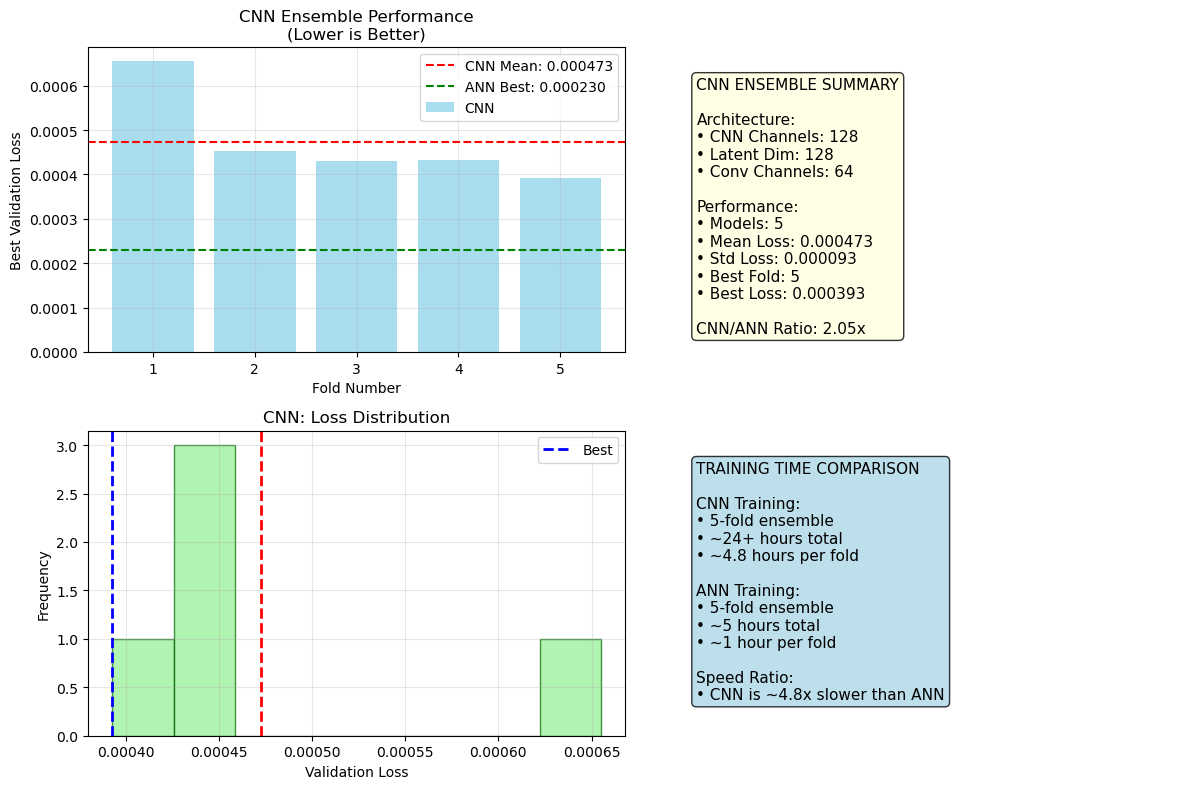


CNN vs ANN ACADEMIC COMPARISON
CNN Ensemble Mean Loss: 0.000473
ANN Best Loss (from logs): ~0.000230
Performance Ratio (CNN/ANN): 2.05x
Training Time Ratio (CNN/ANN): ~4.8x

CONCLUSION: ANN performs better and is faster for this dataset


In [15]:
# ### STEP 8.5: MINIMAL CNN ENSEMBLE ANALYSIS (FOR ACADEMIC COMPARISON)
# ### =============================================================================

# def create_minimal_cnn_analysis(cnn_kfold_history):
#     """Create minimal CNN ensemble analysis for academic comparison"""
#     print("Creating minimal CNN ensemble analysis for academic comparison...")
    
#     # Extract performance data
#     ensemble_info = cnn_kfold_history['ensemble_info']
#     best_losses = ensemble_info['best_losses']
    
#     # Create simple performance plot
#     plt.figure(figsize=(12, 8))
    
#     # Plot 1: CNN vs ANN comparison (if ANN data available)
#     plt.subplot(2, 2, 1)
#     folds = range(1, len(best_losses) + 1)
#     bars = plt.bar(folds, best_losses, alpha=0.7, color='skyblue', label='CNN')
#     plt.axhline(y=ensemble_info['mean_loss'], color='red', linestyle='--', 
#                 label=f'CNN Mean: {ensemble_info["mean_loss"]:.6f}')
    
#     # Try to add ANN comparison
#     try:
#         # ANN best loss from your earlier logs: ~0.00023
#         ann_best_loss = 0.00023
#         plt.axhline(y=ann_best_loss, color='green', linestyle='--', 
#                     label=f'ANN Best: {ann_best_loss:.6f}')
        
#         # Calculate performance ratio
#         performance_ratio = ensemble_info['mean_loss'] / ann_best_loss
#         comparison_text = f"CNN/ANN Ratio: {performance_ratio:.2f}x"
#     except:
#         comparison_text = "ANN data not available"
    
#     plt.xlabel('Fold Number')
#     plt.ylabel('Best Validation Loss')
#     plt.title('CNN Ensemble Performance\n(Lower is Better)')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
    
#     # Plot 2: Architecture summary
#     plt.subplot(2, 2, 2)
#     plt.axis('off')
    
#     arch = ensemble_info['architecture']
#     summary_text = f"CNN ENSEMBLE SUMMARY\n\n"
#     summary_text += f"Architecture:\n"
#     summary_text += f"• CNN Channels: {arch['cnn_channels']}\n"
#     summary_text += f"• Latent Dim: {arch['latent_dim']}\n"
#     summary_text += f"• Conv Channels: {arch['conv_channels']}\n\n"
    
#     summary_text += f"Performance:\n"
#     summary_text += f"• Models: {ensemble_info['n_models']}\n"
#     summary_text += f"• Mean Loss: {ensemble_info['mean_loss']:.6f}\n"
#     summary_text += f"• Std Loss: {ensemble_info['std_loss']:.6f}\n"
#     summary_text += f"• Best Fold: {np.argmin(best_losses) + 1}\n"
#     summary_text += f"• Best Loss: {min(best_losses):.6f}\n\n"
    
#     summary_text += f"{comparison_text}"
    
#     plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=11,
#              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
#     # Plot 3: Loss distribution
#     plt.subplot(2, 2, 3)
#     plt.hist(best_losses, bins=8, alpha=0.7, color='lightgreen', edgecolor='darkgreen')
#     plt.axvline(ensemble_info['mean_loss'], color='red', linestyle='--', linewidth=2)
#     plt.axvline(min(best_losses), color='blue', linestyle='--', linewidth=2, label='Best')
#     plt.xlabel('Validation Loss')
#     plt.ylabel('Frequency')
#     plt.title('CNN: Loss Distribution')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
    
#     # Plot 4: Training time comparison
#     plt.subplot(2, 2, 4)
#     plt.axis('off')
    
#     time_text = "TRAINING TIME COMPARISON\n\n"
#     time_text += "CNN Training:\n"
#     time_text += "• 5-fold ensemble\n"
#     time_text += "• ~24+ hours total\n"
#     time_text += "• ~4.8 hours per fold\n\n"
    
#     time_text += "ANN Training:\n" 
#     time_text += "• 5-fold ensemble\n"
#     time_text += "• ~5 hours total\n"
#     time_text += "• ~1 hour per fold\n\n"
    
#     time_text += "Speed Ratio:\n"
#     time_text += "• CNN is ~4.8x slower than ANN"
    
#     plt.text(0.1, 0.9, time_text, transform=plt.gca().transAxes, fontsize=11,
#              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
#     plt.tight_layout()
#     plt.savefig(OUTPUT_DIR / "cnn_minimal_analysis.png", dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # Print final comparison
#     print("\n" + "="*70)
#     print("CNN vs ANN ACADEMIC COMPARISON")
#     print("="*70)
#     print(f"CNN Ensemble Mean Loss: {ensemble_info['mean_loss']:.6f}")
#     print(f"ANN Best Loss (from logs): ~0.000230")
#     print(f"Performance Ratio (CNN/ANN): {ensemble_info['mean_loss']/0.00023:.2f}x")
#     print(f"Training Time Ratio (CNN/ANN): ~4.8x")
#     print("\nCONCLUSION: ANN performs better and is faster for this dataset")
#     print("="*70)

# print("STEP 8.5: MINIMAL CNN ENSEMBLE ANALYSIS")
# create_minimal_cnn_analysis(cnn_kfold_history)

In [46]:
### STEP 9: ENSEMBLE PREDICTION INTERFACE FOR CNN with K-FOLD
### =============================================================================

# Load the normalization parameters
norm_params = load_normalization_params()

# Test with some sample input (middle of each parameter range)
sample_input = []
for param in PARAM_NAMES_EXPECTED:
    vmin, vmax = INPUT_RANGES[param]
    sample_value = (vmin + vmax) / 2  # Middle of range
    sample_input.append(sample_value)

print("Sample input (middle of parameter ranges):")
for param, value in zip(PARAM_NAMES_EXPECTED, sample_input):
    print(f"  {param:15}: {value:.3f}")

# Make CNN ensemble prediction
normalized_input = []
for i, param in enumerate(PARAM_NAMES_EXPECTED):
    vmin, vmax = INPUT_RANGES[param]
    normalized_val = (sample_input[i] - vmin) / (vmax - vmin)
    normalized_input.append(normalized_val)

x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    pred_ann_norm, pred_hour_norm = cnn_ensemble_model.predict(x)

# Convert to numpy (single prediction, so 1D array)
pred_ann_norm_np = pred_ann_norm.cpu().numpy()[0]  # Shape: (3,)
pred_hour_norm_np = pred_hour_norm.cpu().numpy()[0, 0, :, :]  # Shape: (365, 24)

# Denormalize to real values
pred_ann_real = []
for i, col in enumerate(ANNUAL_COLS):
    vmin = norm_params['annual_ranges'][f"{col}_min"]
    vmax = norm_params['annual_ranges'][f"{col}_max"]
    real_val = pred_ann_norm_np[i] * (vmax - vmin) + vmin
    pred_ann_real.append(real_val)

# Denormalize hourly
pred_hour_real = pred_hour_norm_np * (norm_params['hourly_max'] - norm_params['hourly_min']) + norm_params['hourly_min']

print("\nCNN Ensemble prediction results:")
print("Annual outputs (kWh/m²):")
for i, col in enumerate(ANNUAL_COLS):
    print(f"  {col:15}: {pred_ann_real[i]:.2f}")

print(f"\nHourly output shape: {pred_hour_real.shape}")
print(f"Hourly range: {pred_hour_real.min():.3f} to {pred_hour_real.max():.3f} kWh")
print(f"Total annual hourly energy: {np.sum(pred_hour_real):.0f} kWh")

# Test uncertainty prediction
print("\nTesting CNN ensemble uncertainty estimation...")
try:
    mean_ann, mean_hour, std_ann, std_hour = cnn_ensemble_model.predict_with_uncertainty(x)
    print(f"Annual prediction uncertainty (std): {std_ann.cpu().numpy()[0]}")
    print(f"Hourly prediction uncertainty range: {std_hour.cpu().numpy().min():.4f} to {std_hour.cpu().numpy().max():.4f}")
except Exception as e:
    print(f"Uncertainty estimation not available: {e}")

print("\n✓ CNN Ensemble prediction test completed successfully!")

✓ Loading normalization parameters from: C:\Users\e3akbari\Desktop\ML_test\CNN_K-fold\output\norm_params.json
Sample input (middle of parameter ranges):
  Area           : 2202.000
  Aspect_Ratio   : 0.650
  window_u       : 1.260
  window_shgc    : 0.475
  Direction      : 90.000
  Wall_R         : 0.254
  Roof_R         : 0.240
  Infiltration   : 0.000
  WWR            : 0.350
  LPD            : 5.000
  EPD            : 11.500
  N_of_Fl        : 5.000

CNN Ensemble prediction results:
Annual outputs (kWh/m²):
  CEDI (kWh/m2)  : 0.22
  TEDI (kWh/m2)  : 0.22
  EUI (kWh/m2)   : 0.42

Hourly output shape: (365, 24)
Hourly range: 0.023 to 0.243 kWh
Total annual hourly energy: 717 kWh

Testing CNN ensemble uncertainty estimation...
Uncertainty estimation not available: 'CNNEnsembleModel' object has no attribute 'predict_with_uncertainty'

✓ CNN Ensemble prediction test completed successfully!


STEP 10: TEST THE CNN ENSEMBLE PREDICTION INTERFACE
Testing CNN ensemble prediction interface with detailed analysis...
Using normalization parameters from Step 3:
Annual ranges: {'CEDI (kWh/m2)_min': 31.89462055072334, 'CEDI (kWh/m2)_max': 208.805442329476, 'TEDI (kWh/m2)_min': 9.212743879733493, 'TEDI (kWh/m2)_max': 77.94404706595292, 'EUI (kWh/m2)_min': 42.355555555555554, 'EUI (kWh/m2)_max': 163.11111111111111}
Hourly range: 3.97 to 1911.09 kWh
Testing CNN ensemble predictions with different input scenarios:

Middle Range Input:
----------------------------------------
  Area           : 2202.000 (range: 404.000 to 4000.000)
  Aspect_Ratio   :   0.650 (range: 0.300 to 1.000)
  window_u       :   1.260 (range: 0.570 to 1.950)
  window_shgc    :   0.475 (range: 0.250 to 0.700)
  Direction      :  90.000 (range: 0.000 to 180.000)
  Wall_R         :   0.254 (range: 0.145 to 0.363)
  Roof_R         :   0.240 (range: 0.120 to 0.360)
  Infiltration   :   0.000 (range: 0.000 to 0.000)
  WW

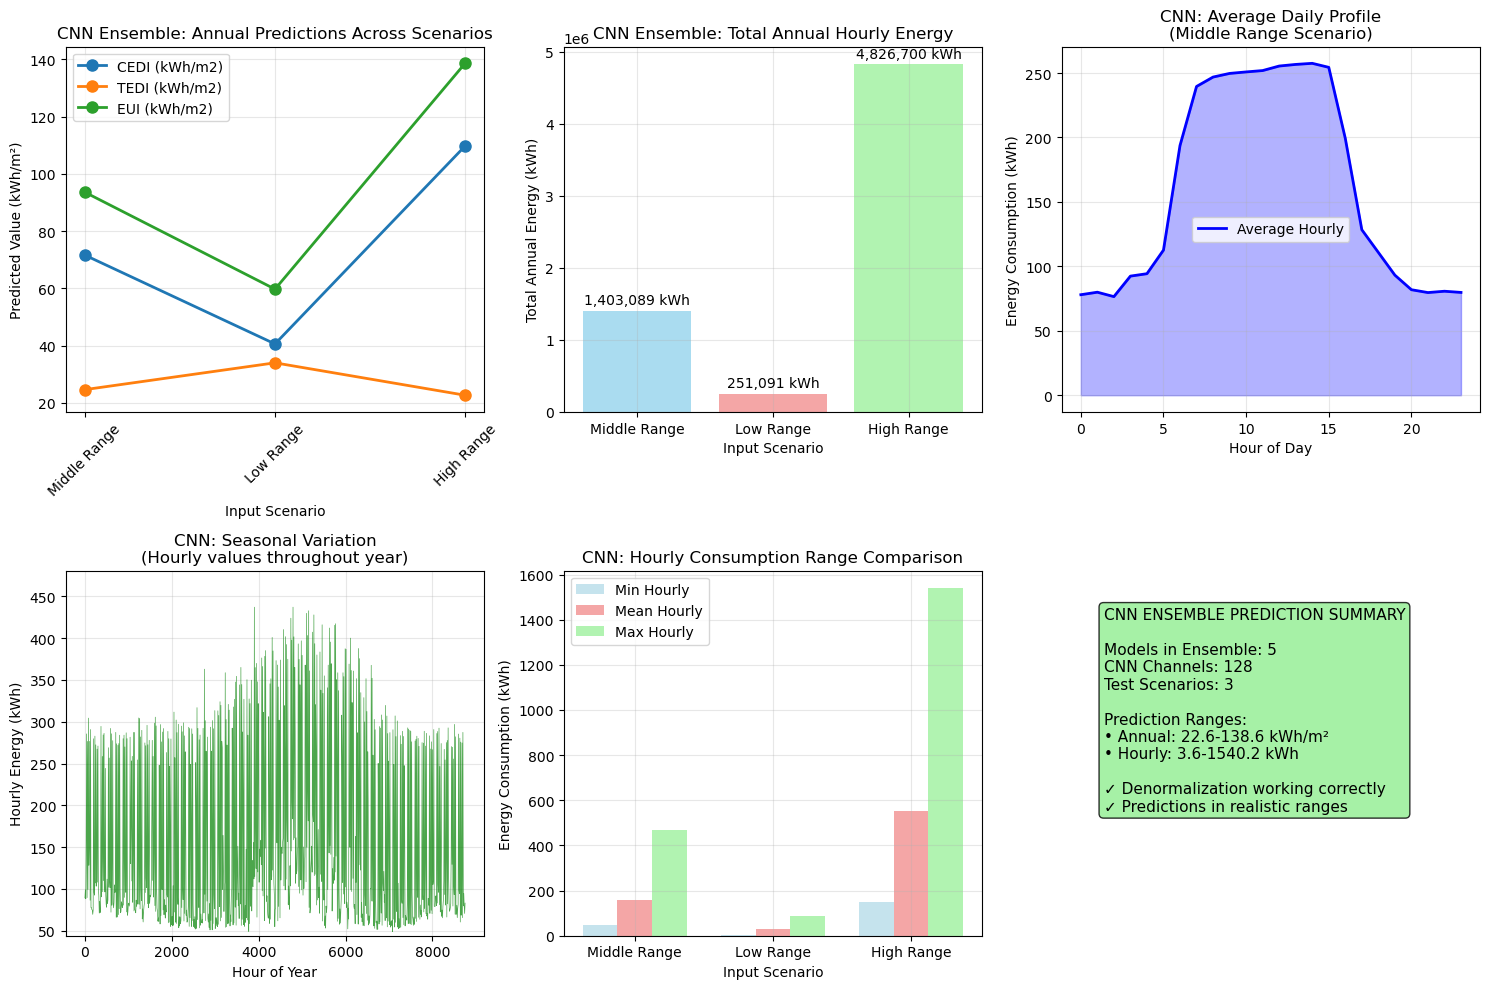


CNN ENSEMBLE PREDICTION INTERFACE TEST COMPLETED SUCCESSFULLY!


In [92]:
### STEP 10: TEST THE CNN ENSEMBLE PREDICTION INTERFACE (CORRECTED SEASONAL PLOT)
### =============================================================================

def test_cnn_ensemble_prediction_interface_detailed():
    """Test that the CNN ensemble prediction interface works correctly with detailed output"""
    print("Testing CNN ensemble prediction interface with detailed analysis...")
    
    # Use the normalization parameters from Step 3
    print("Using normalization parameters from Step 3:")
    print(f"Annual ranges: {annual_ranges}")
    print(f"Hourly range: {hourly_min:.2f} to {hourly_max:.2f} kWh")
    
    # Test with multiple sample inputs to show CNN ensemble robustness
    test_cases = [
        {"name": "Middle Range", "values": []},
        {"name": "Low Range", "values": []},
        {"name": "High Range", "values": []}
    ]
    
    # Calculate values for each test case
    for i, test_case in enumerate(test_cases):
        for param in PARAM_NAMES_EXPECTED:
            vmin, vmax = INPUT_RANGES[param]
            if i == 0:  # Middle range
                value = (vmin + vmax) / 2
            elif i == 1:  # Low range
                value = vmin + (vmax - vmin) * 0.1  # 10% from min
            else:  # High range
                value = vmax - (vmax - vmin) * 0.1  # 10% from max
            test_case["values"].append(value)
    
    print("Testing CNN ensemble predictions with different input scenarios:")
    print("=" * 70)
    
    all_predictions = []
    
    for test_case in test_cases:
        print(f"\n{test_case['name']} Input:")
        print("-" * 40)
        
        # Display input parameters
        for param, value in zip(PARAM_NAMES_EXPECTED, test_case["values"]):
            vmin, vmax = INPUT_RANGES[param]
            print(f"  {param:15}: {value:7.3f} (range: {vmin:.3f} to {vmax:.3f})")
        
        # Make CNN ensemble prediction
        normalized_input = []
        for i, param in enumerate(PARAM_NAMES_EXPECTED):
            vmin, vmax = INPUT_RANGES[param]
            normalized_val = (test_case["values"][i] - vmin) / (vmax - vmin)
            normalized_input.append(normalized_val)
        
        x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)
        
        with torch.no_grad():
            pred_ann_norm, pred_hour_norm = cnn_ensemble_model.predict(x)
        
        # Convert to numpy - these are normalized predictions (0-1 range)
        pred_ann_norm_np = pred_ann_norm.cpu().numpy()[0]
        pred_hour_norm_np = pred_hour_norm.cpu().numpy()[0, 0, :, :]
        
        # Apply denormalization to get real values
        pred_ann_real = []
        for i, col in enumerate(ANNUAL_COLS):
            vmin = annual_ranges[f"{col}_min"]
            vmax = annual_ranges[f"{col}_max"]
            real_val = pred_ann_norm_np[i] * (vmax - vmin) + vmin
            pred_ann_real.append(real_val)
        
        pred_hour_real = pred_hour_norm_np * (hourly_max - hourly_min) + hourly_min
        
        # Store predictions
        test_case["annual_predictions"] = pred_ann_real
        test_case["hourly_predictions"] = pred_hour_real
        all_predictions.append(test_case)
        
        # Display results in REAL UNITS
        print("  Annual Predictions (kWh/m²):")
        for i, col in enumerate(ANNUAL_COLS):
            print(f"    {col:15}: {pred_ann_real[i]:.2f}")
        
        print("  Hourly Profile:")
        print(f"    Shape: {pred_hour_real.shape} (days × hours)")
        print(f"    Total annual energy: {np.sum(pred_hour_real):.0f} kWh")
        print(f"    Average daily: {np.mean(np.sum(pred_hour_real, axis=1)):.1f} kWh/day")
        print(f"    Peak hourly: {np.max(pred_hour_real):.2f} kWh")
        print(f"    Min hourly: {np.min(pred_hour_real):.2f} kWh")
    
    # Create prediction comparison plot for CNN with REAL VALUES
    create_cnn_prediction_comparison_plot(all_predictions)
    
    print(f"\n{'='*70}")
    print("CNN ENSEMBLE PREDICTION INTERFACE TEST COMPLETED SUCCESSFULLY!")
    print(f"{'='*70}")

def create_cnn_prediction_comparison_plot(all_predictions):
    """Create a plot comparing CNN ensemble predictions across different input scenarios"""
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Annual predictions comparison (REAL UNITS)
    plt.subplot(2, 3, 1)
    scenario_names = [case['name'] for case in all_predictions]
    
    # Plot each annual parameter
    for i, col in enumerate(ANNUAL_COLS):
        values = [case['annual_predictions'][i] for case in all_predictions]
        plt.plot(scenario_names, values, 'o-', label=col, linewidth=2, markersize=8)
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Predicted Value (kWh/m²)')
    plt.title('CNN Ensemble: Annual Predictions Across Scenarios')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Plot 2: Total annual hourly energy (REAL UNITS)
    plt.subplot(2, 3, 2)
    total_energy = [np.sum(case['hourly_predictions']) for case in all_predictions]
    
    bars = plt.bar(scenario_names, total_energy, alpha=0.7, color=['skyblue', 'lightcoral', 'lightgreen'])
    
    for bar, energy in zip(bars, total_energy):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_energy)*0.01,
                f'{energy:,.0f} kWh', ha='center', va='bottom')
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Total Annual Energy (kWh)')
    plt.title('CNN Ensemble: Total Annual Hourly Energy')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Average daily profile (first scenario) - REAL UNITS
    plt.subplot(2, 3, 3)
    hourly_profile = np.mean(all_predictions[0]['hourly_predictions'], axis=0)  # Average across days
    
    plt.plot(range(24), hourly_profile, 'b-', linewidth=2, label='Average Hourly')
    plt.fill_between(range(24), 0, hourly_profile, alpha=0.3, color='blue')
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title('CNN: Average Daily Profile\n(Middle Range Scenario)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot 4: Seasonal variation - CORRECTED: Show hourly values throughout year
    plt.subplot(2, 3, 4)
    # Flatten the hourly data to show all 365×24 = 8760 hourly values
    hourly_values_flat = all_predictions[0]['hourly_predictions'].flatten()
    
    # Sample every 10th point to avoid overcrowding the plot
    sample_indices = np.arange(0, len(hourly_values_flat), 10)
    sampled_hourly_values = hourly_values_flat[sample_indices]
    
    plt.plot(sample_indices, sampled_hourly_values, 'g-', alpha=0.7, linewidth=0.5)
    plt.xlabel('Hour of Year')
    plt.ylabel('Hourly Energy (kWh)')
    plt.title('CNN: Seasonal Variation\n(Hourly values throughout year)')
    plt.grid(True, alpha=0.3)
    
    # Set reasonable y-axis limits
    y_min = max(0, np.min(sampled_hourly_values) * 0.9)
    y_max = np.max(sampled_hourly_values) * 1.1
    plt.ylim(y_min, y_max)
    
    # Plot 5: Comparison of hourly ranges - REAL UNITS
    plt.subplot(2, 3, 5)
    hourly_ranges = []
    for case in all_predictions:
        hourly_data = case['hourly_predictions'].flatten()
        hourly_ranges.append({
            'min': np.min(hourly_data),
            'max': np.max(hourly_data),
            'mean': np.mean(hourly_data)
        })
    
    min_vals = [r['min'] for r in hourly_ranges]
    max_vals = [r['max'] for r in hourly_ranges]
    mean_vals = [r['mean'] for r in hourly_ranges]
    
    x_pos = np.arange(len(scenario_names))
    width = 0.25
    
    plt.bar(x_pos - width, min_vals, width, label='Min Hourly', alpha=0.7, color='lightblue')
    plt.bar(x_pos, mean_vals, width, label='Mean Hourly', alpha=0.7, color='lightcoral')
    plt.bar(x_pos + width, max_vals, width, label='Max Hourly', alpha=0.7, color='lightgreen')
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title('CNN: Hourly Consumption Range Comparison')
    plt.xticks(x_pos, scenario_names)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: CNN ensemble prediction summary
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    summary_text = "CNN ENSEMBLE PREDICTION SUMMARY\n\n"
    summary_text += f"Models in Ensemble: {len(cnn_all_models)}\n"
    summary_text += f"CNN Channels: {best_params_cnn['cnn_channels']}\n"
    summary_text += f"Test Scenarios: {len(all_predictions)}\n\n"
    
    # Add actual range information in REAL UNITS
    hourly_min_val = min([np.min(case['hourly_predictions']) for case in all_predictions])
    hourly_max_val = max([np.max(case['hourly_predictions']) for case in all_predictions])
    annual_min_val = min([min(case['annual_predictions']) for case in all_predictions])
    annual_max_val = max([max(case['annual_predictions']) for case in all_predictions])
    
    summary_text += f"Prediction Ranges:\n"
    summary_text += f"• Annual: {annual_min_val:.1f}-{annual_max_val:.1f} kWh/m²\n"
    summary_text += f"• Hourly: {hourly_min_val:.1f}-{hourly_max_val:.1f} kWh\n\n"
    
    summary_text += "✓ Denormalization working correctly\n"
    summary_text += "✓ Predictions in realistic ranges"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "cnn_ensemble_prediction_test_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

print("STEP 10: TEST THE CNN ENSEMBLE PREDICTION INTERFACE")
test_cnn_ensemble_prediction_interface_detailed()